# 잔존수명 예측 모델

입력: 진동 피처 + t_abs(절대 경과 시간) + rpm_pred + initial_fault_intensity
출력: RUL (초)

Train 학습:
  각 1초 샘플의 피처 → 해당 시점의 실제 RUL

Validation 예측:
  마지막 epoch의 피처 → RUL 예측

Train4 : 후방 축방향 결함으로 축방향 하중이 크지만 결함이 특정 방향에 집중되어 전체 베어링 파괴까지 시간이 더 걸렸을 수 있음 > initial intensity facgtor로 잡았다고 예상          
Train3 : 전방 축방향 결함으로 수명이 짧고, 점진적 열화인 다른 train에 비해 급작스런 패턴

In [19]:
# !pip install common_utils
# !pip install torch
# !pip install openpyxl

In [2]:
import numpy as np
import pandas as pd
import platform
import os, random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from common_utils import (load_train_data, load_test_data,
                          get_feat_cols, add_trend_features, aggregate_epoch,
                          calc_score, plot_loo_results,
                          fix_seed, SEED, TRAIN_PATH, TEST_PATH)
# import torch 
# import torch.nn as nn 
# from torch.utils.data import DataLoader, TensorDataset 

In [3]:
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.family'] = 'AppleGothic'
    else:  # Linux (서버 환경)
        # 나눔 폰트 설치 후 사용
        # sudo apt-get install fonts-nanum
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                      capture_output=True)
        fm._load_fontmanager(try_read_cache=False)
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        font_prop = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font_prop.get_name()

    plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

set_korean_font()

In [4]:
fix_seed()

## 최종 모델 : 앙상블 ttf/ln(RUL) xgboost 모델

- 슬라이싱 마지막 행 샘플링
- alpha = 0.5

In [ ]:
XGB_PARAMS = dict(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, verbosity=0,
)
TRAIN_CUTOFFS  = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]  # TTF 학습 + log 학습
VALID_CUTOFFS  = [0.2, 0.5, 0.8]                   # Valid 확인
EXCLUDE_COLS   = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                  'rpm', 'train_id', 'test_id']

In [ ]:
# ============================================================
# 공통 함수 정의
# ============================================================
def calc_sample_weights(values):
    """말기에 높은 가중치 (v^2 정규화)"""
    v = np.array(values, dtype=np.float32)
    w = v ** 2
    return (w / w.mean()).astype(np.float32)


def make_cutoff_samples(df, cutoffs):
    """각 cutoff 시점의 마지막 행 피처 + TTF/RUL"""
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])
        for co in cutoffs:
            df_cut = df_t[df_t['t_abs'] <= ttf * co]
            if len(df_cut) == 0:
                continue
            last = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul  = float(ttf - last['t_abs'])
            samples.append({
                'train_id': tid, 'cutoff': co,
                'ttf': ttf,      'RUL':    rul,
                't_abs': float(last['t_abs']),
                **{c: last[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)


def get_last_rows(df, cutoffs):
    """각 cutoff 시점의 마지막 행 추출 (예측용)"""
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid]
        ttf  = float(df_t['ttf'].iloc[0])
        for co in cutoffs:
            df_cut = df_t[df_t['t_abs'] <= ttf * co]
            if len(df_cut) == 0:
                continue
            last = df_cut.loc[df_cut['t_abs'].idxmax()].to_frame().T.copy()
            last['cutoff']   = co
            last['train_id'] = tid
            samples.append(last)
    return pd.concat(samples, ignore_index=True)


def make_log_samples_split(df, cutoffs, train_ratio=0.8):
    """
    TRAIN_CUTOFFS 각 cutoff까지의 데이터를 train_ratio로 분리
      상위 train_ratio(80%) 행 → log(RUL) 학습
      하위 1-train_ratio(20%) 행 → 내부 검증용
    """
    train_rows = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])
        for co in cutoffs:
            df_cut = df_t[df_t['t_abs'] <= ttf * co].copy()
            if len(df_cut) < 10:
                continue
            n_train = int(len(df_cut) * train_ratio)
            train_rows.append(df_cut.iloc[:n_train])  # 상위 80%
    return pd.concat(train_rows, ignore_index=True).drop_duplicates()

In [ ]:
# ============================================================
# 기존 방식 (선택 A)
# TTF: cutoff 기반 24샘플
# log: cutoff 기반 24샘플
# 균형 점수 = LOO평균×0.3 + Train3_LOO×0.3 + Valid평균×0.4
# ============================================================

fix_seed()

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10],
                              group_col='train_id')
df_feat = df_feat.copy().fillna(0)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]

# ── 두 모델 학습 (동일한 cutoff 기반 24샘플) ─────────────────
df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
m_ttf = XGBRegressor(**XGB_PARAMS)
m_ttf.fit(X_train,
          df_train_s['ttf'].values.astype(np.float32),
          sample_weight=weights)

fix_seed()
m_log = XGBRegressor(**XGB_PARAMS)
m_log.fit(X_train,
          np.log1p(df_train_s['RUL'].values).astype(np.float32),
          sample_weight=weights)

# ── Valid 예측 ────────────────────────────────────────────────
rul_ttf_v = np.maximum(
    m_ttf.predict(X_valid).astype(np.float32) -
    df_valid_s['t_abs'].values, 0)
rul_log_v = np.maximum(
    np.expm1(m_log.predict(X_valid).astype(np.float32)), 0)
act_rul_v = df_valid_s['RUL'].values

# ── alpha별 Valid 성능 ────────────────────────────────────────
print('=== alpha 탐색 (Valid 기준) ===')
print(f'{"α":>6} | {"전체":>8} | {"T1":>8} | '
      f'{"T2":>8} | {"T3":>8} | {"T4":>8}')
print('-' * 55)

alpha_valid = {}
for alpha in np.arange(0.0, 1.05, 0.1):
    alpha  = round(float(alpha), 1)
    pred   = alpha * rul_log_v + (1 - alpha) * rul_ttf_v
    sc     = [calc_score(a, p) for a, p in zip(act_rul_v, pred)]
    avg    = float(np.mean(sc))
    t_sc   = {}
    for t in [1, 2, 3, 4]:
        mask    = df_valid_s['train_id'].values == t
        t_sc[t] = float(np.mean([sc[i] for i in range(len(sc))
                                  if mask[i]]))
    alpha_valid[alpha] = {'valid_avg': avg, 'valid_t3': t_sc[3]}
    print(f'{alpha:>6.1f} | {avg:>8.4f} | {t_sc[1]:>8.4f} | '
          f'{t_sc[2]:>8.4f} | {t_sc[3]:>8.4f} | {t_sc[4]:>8.4f}')

# ── LOO 검증 + 균형 점수 ──────────────────────────────────────
print('\n=== LOO 검증 (alpha별) ===')
print(f'{"α":>6} | {"균형점수":>10} | {"LOO평균":>8} | '
      f'{"LOO_T3":>8} | {"Valid":>8}')
print('-' * 55)

best_alpha, best_bal = 0.0, -1
alpha_all = {}

for alpha in np.arange(0.0, 1.05, 0.1):
    alpha    = round(float(alpha), 1)
    loo_list = []
    loo_per  = {}

    for val_id in [1, 2, 3, 4]:
        train_ids = [t for t in [1,2,3,4] if t != val_id]
        df_tr_loo = df_feat[df_feat['train_id'].isin(train_ids)]
        df_va_loo = df_feat[df_feat['train_id'] == val_id]

        df_tr_s = make_cutoff_samples(
            df_tr_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
        df_va_s = make_cutoff_samples(df_va_loo, VALID_CUTOFFS)

        X_tr = df_tr_s[feat_cols].values.astype(np.float32)
        X_va = df_va_s[feat_cols].values.astype(np.float32)
        w_tr = calc_sample_weights(df_tr_s['cutoff'].values)

        fix_seed()
        lt = XGBRegressor(**XGB_PARAMS)
        lt.fit(X_tr,
               df_tr_s['ttf'].values.astype(np.float32),
               sample_weight=w_tr)

        fix_seed()
        ll = XGBRegressor(**XGB_PARAMS)
        ll.fit(X_tr,
               np.log1p(df_tr_s['RUL'].values).astype(np.float32),
               sample_weight=w_tr)

        rul_t = np.maximum(
            lt.predict(X_va).astype(np.float32) -
            df_va_s['t_abs'].values, 0)
        rul_l = np.maximum(
            np.expm1(ll.predict(X_va).astype(np.float32)), 0)

        pred   = alpha * rul_l + (1 - alpha) * rul_t
        act    = df_va_s['RUL'].values
        scores = [calc_score(a, p) for a, p in zip(act, pred)]
        loo_per[val_id] = float(np.mean(scores))
        loo_list.append(loo_per[val_id])

    loo_avg  = float(np.mean(loo_list))
    t3_loo   = loo_per[3]
    v_avg    = alpha_valid[alpha]['valid_avg']
    balanced = 0.3*loo_avg + 0.3*t3_loo + 0.4*v_avg

    alpha_all[alpha] = {
        'balanced': balanced, 'loo_avg': loo_avg,
        't3_loo': t3_loo,     'valid_avg': v_avg
    }
    print(f'{alpha:>6.1f} | {balanced:>10.4f} | {loo_avg:>8.4f} | '
          f'{t3_loo:>8.4f} | {v_avg:>8.4f}')

    if balanced > best_bal:
        best_bal, best_alpha = balanced, alpha

print(f'\n=== 최적 alpha: {best_alpha} ===')
print(f'  균형 점수:  {alpha_all[best_alpha]["balanced"]:.4f}')
print(f'  LOO 평균:   {alpha_all[best_alpha]["loo_avg"]:.4f}')
print(f'  Train3 LOO: {alpha_all[best_alpha]["t3_loo"]:.4f}')
print(f'  Valid 평균: {alpha_all[best_alpha]["valid_avg"]:.4f}')

=== alpha 탐색 (Valid 기준) ===
     α |       전체 |       T1 |       T2 |       T3 |       T4
-------------------------------------------------------
   0.0 |   0.8795 |   0.8100 |   0.9710 |   0.8191 |   0.9179
   0.1 |   0.8487 |   0.7821 |   0.9491 |   0.7288 |   0.9350
   0.2 |   0.7905 |   0.7561 |   0.8995 |   0.6600 |   0.8465
   0.3 |   0.7346 |   0.7321 |   0.8536 |   0.6063 |   0.7466
   0.4 |   0.6875 |   0.7097 |   0.8109 |   0.5635 |   0.6661
   0.5 |   0.6472 |   0.6889 |   0.7712 |   0.5285 |   0.6004
   0.6 |   0.6122 |   0.6695 |   0.7343 |   0.4991 |   0.5459
   0.7 |   0.5814 |   0.6514 |   0.7000 |   0.4739 |   0.5002
   0.8 |   0.5539 |   0.6346 |   0.6679 |   0.4519 |   0.4611
   0.9 |   0.5291 |   0.6188 |   0.6381 |   0.4323 |   0.4274
   1.0 |   0.5067 |   0.6040 |   0.6102 |   0.4146 |   0.3978

=== LOO 검증 (alpha별) ===
     α |       균형점수 |    LOO평균 |   LOO_T3 |    Valid
-------------------------------------------------------
   0.0 |     0.5479 |   0.4507 |   0.2

In [ ]:
# ===alpha 탐색
# =====LOO 검증

=== alpha 탐색 (Valid 기준) ===
     α |     A_전체 |     A_T3 |     B_전체 |     B_T3
-------------------------------------------------------
   0.0 |   0.8795 |   0.8191 |   1.0000 |   1.0000
   0.1 |   0.8487 |   0.7288 |   0.9981 |   0.9978
   0.2 |   0.7905 |   0.6600 |   0.9962 |   0.9955
   0.3 |   0.7346 |   0.6063 |   0.9944 |   0.9933
   0.4 |   0.6875 |   0.5635 |   0.9925 |   0.9912
   0.5 |   0.6472 |   0.5285 |   0.9906 |   0.9890
   0.6 |   0.6122 |   0.4991 |   0.9888 |   0.9868
   0.7 |   0.5814 |   0.4739 |   0.9869 |   0.9846
   0.8 |   0.5539 |   0.4519 |   0.9851 |   0.9824
   0.9 |   0.5291 |   0.4323 |   0.9832 |   0.9803
   1.0 |   0.5067 |   0.4146 |   0.9814 |   0.9781

방법 A 최적 alpha=0.0 | Score=0.8795
방법 B 최적 alpha=0.0 | Score=1.0000



=== LOO: 방법 A (cutoff) (alpha=0.0) ===
  Val=Train1 | Score=0.4410
  Val=Train2 | Score=0.5583
  Val=Train3 | Score=0.2029
  Val=Train4 | Score=0.6004
  LOO 평균: 0.4507 | Train3 LOO: 0.2029

=== LOO: 방법 B (행별) (alpha=0.0) ===
  Val=Train1 | Score=0.5947
  Val=Train2 | Score=0.4968
  Val=Train3 | Score=0.2431
  Val=Train4 | Score=0.7264
  LOO 평균: 0.5152 | Train3 LOO: 0.2431


In [18]:
# ============================================================
# Cell 4 수정: 혼합 방식
# TTF: 9 cutoff × 4 Train = 36샘플
# log(RUL): cutoff 내 80% 학습, 20% 검증
# ============================================================

# ── TTF 모델: 9 cutoff 기반 ───────────────────────────────────
TRAIN_CUTOFFS_9 = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

df_train_c = make_cutoff_samples(df_feat, TRAIN_CUTOFFS_9)
feat_cols  = [c for c in df_train_c.columns
              if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
weights_c  = calc_sample_weights(df_train_c['cutoff'].values)

print(f'TTF 모델 | Train 샘플: {len(df_train_c)}개 '
      f'(9 cutoff × 4 Train)')

fix_seed()
m_ttf = XGBRegressor(**XGB_PARAMS)
m_ttf.fit(df_train_c[feat_cols].values.astype(np.float32),
          df_train_c['ttf'].values.astype(np.float32),
          sample_weight=weights_c)

# ── log(RUL) 모델: cutoff 내 80/20 분리 ──────────────────────
def make_log_samples_split(df, cutoffs, train_ratio=0.8):
    """
    각 cutoff 구간 내에서
    상위 train_ratio 행 → 학습
    하위 (1-train_ratio) 행 → 검증 (마지막 구간)
    """
    train_rows, valid_rows = [], []

    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])

        for co in cutoffs:
            df_cut = df_t[df_t['t_abs'] <= ttf * co].copy()
            if len(df_cut) < 10:
                continue

            n_train = int(len(df_cut) * train_ratio)
            df_tr   = df_cut.iloc[:n_train]
            df_va   = df_cut.iloc[n_train:]

            train_rows.append(df_tr)
            valid_rows.append(df_va)

    df_train = pd.concat(train_rows, ignore_index=True).drop_duplicates()
    df_valid = pd.concat(valid_rows, ignore_index=True).drop_duplicates()
    return df_train, df_valid


df_train_r, df_valid_r = make_log_samples_split(
    df_feat, TRAIN_CUTOFFS_9, train_ratio=0.8)

feat_cols_r = [c for c in df_train_r.columns
               if c not in EXCLUDE_COLS + ['train_id']]
weights_r   = calc_sample_weights(
    (df_train_r['t_abs'] / df_train_r['ttf']).values)

print(f'log 모델 | Train 행: {len(df_train_r)}개 | '
      f'Valid 행: {len(df_valid_r)}개')

fix_seed()
m_log = XGBRegressor(**XGB_PARAMS)
m_log.fit(df_train_r[feat_cols_r].values.astype(np.float32),
          np.log1p(df_train_r['RUL'].values).astype(np.float32),
          sample_weight=weights_r)

# ── Valid 예측 ────────────────────────────────────────────────
# TTF valid: 각 cutoff 마지막 행
df_valid_c = get_last_rows(df_feat, [0.2, 0.5, 0.8])

rul_ttf_v = np.maximum(
    m_ttf.predict(
        df_valid_c[feat_cols].values.astype(np.float32)
    ).astype(np.float32) -
    df_valid_c['t_abs'].values.astype(float), 0)

# log valid: 각 cutoff의 하위 20% 마지막 행
df_valid_r_last = df_valid_r.sort_values(
    ['train_id', 't_abs']).groupby('train_id').last().reset_index()

# cutoff별 마지막 행으로 정리
valid_last_rows = []
for tid in df_feat['train_id'].unique():
    df_t = df_feat[df_feat['train_id'] == tid]
    ttf  = float(df_t['ttf'].iloc[0])
    for co in [0.2, 0.5, 0.8]:
        df_cut = df_t[df_t['t_abs'] <= ttf * co]
        if len(df_cut) < 10:
            continue
        n_train = int(len(df_cut) * 0.8)
        # 하위 20% 구간의 마지막 행
        last = df_cut.iloc[n_train:].iloc[-1].to_frame().T.copy()
        last['cutoff']   = co
        last['train_id'] = tid
        valid_last_rows.append(last)

df_valid_log_last = pd.concat(valid_last_rows, ignore_index=True)

rul_log_v  = np.maximum(
    np.expm1(m_log.predict(
        df_valid_log_last[feat_cols_r].values.astype(np.float32)
    )), 0)
act_rul_v  = df_valid_log_last['RUL'].values.astype(float)

print('혼합 방식 학습 완료')
print(f'  TTF: 36샘플(cutoff 기반) | log: {len(df_train_r)}행(80/20 분리)')

TTF 모델 | Train 샘플: 36개 (9 cutoff × 4 Train)
log 모델 | Train 행: 20112개 | Valid 행: 19486개
혼합 방식 학습 완료
  TTF: 36샘플(cutoff 기반) | log: 20112행(80/20 분리)


C:\Users\이하연\AppData\Local\Temp\ipykernel_10580\2585893941.py:83: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ['train_id', 't_abs']).groupby('train_id').last().reset_index()


In [20]:
# ============================================================
# Cell 5: alpha 탐색 + LOO
# ============================================================
print('=== alpha 탐색 (Valid 기준) ===')
print(f'{"α":>6} | {"Valid전체":>10} | {"Valid_T3":>10}')
print('-' * 35)

alpha_valid = {}
for alpha in np.arange(0.0, 1.05, 0.1):
    alpha = round(float(alpha), 1)

    # TTF valid와 log valid 순서 맞추기
    rul_ttf_unified = np.maximum(
        m_ttf.predict(
            df_valid_log_last[feat_cols].values.astype(np.float32)
        ).astype(np.float32) -
        df_valid_log_last['t_abs'].values.astype(float), 0)

    pred  = alpha * rul_log_v + (1 - alpha) * rul_ttf_unified
    sc    = [calc_score(a, p) for a, p in zip(act_rul_v, pred)]
    avg   = float(np.mean(sc))
    mask3 = df_valid_log_last['train_id'].values.astype(int) == 3
    t3    = float(np.mean([sc[i] for i in range(len(sc)) if mask3[i]]))

    alpha_valid[alpha] = {'valid_avg': avg, 'valid_t3': t3}
    print(f'{alpha:>6.1f} | {avg:>10.4f} | {t3:>10.4f}')

# LOO
print('\n=== LOO 검증 (alpha별) ===')
print(f'{"α":>6} | {"균형점수":>10} | {"LOO평균":>8} | '
      f'{"LOO_T3":>8} | {"Valid":>8}')
print('-' * 55)

best_alpha, best_bal = 0.0, -1
alpha_all = {}

for alpha in np.arange(0.0, 1.05, 0.1):
    alpha    = round(float(alpha), 1)
    loo_list = []
    loo_per  = {}

    for val_id in [1, 2, 3, 4]:
        train_ids = [t for t in [1,2,3,4] if t != val_id]
        df_tr_loo = df_feat[df_feat['train_id'].isin(train_ids)]
        df_va_loo = df_feat[df_feat['train_id'] == val_id]

        # TTF LOO: cutoff 기반
        df_tr_c = make_cutoff_samples(df_tr_loo, TRAIN_CUTOFFS_9)
        df_va_c = get_last_rows(df_va_loo, [0.2, 0.5, 0.8])

        fix_seed()
        lt = XGBRegressor(**XGB_PARAMS)
        lt.fit(df_tr_c[feat_cols].values.astype(np.float32),
               df_tr_c['ttf'].values.astype(np.float32),
               sample_weight=calc_sample_weights(
                   df_tr_c['cutoff'].values))

        # log LOO: 80/20 분리
        df_tr_r, _ = make_log_samples_split(
            df_tr_loo, TRAIN_CUTOFFS_9, train_ratio=0.8)

        # valid: val_id의 각 cutoff 80/20 하위 마지막 행
        va_log_rows = []
        for co in [0.2, 0.5, 0.8]:
            df_t   = df_va_loo.copy()
            ttf_v  = float(df_t['ttf'].iloc[0])
            df_cut = df_t[df_t['t_abs'] <= ttf_v * co]
            if len(df_cut) < 10:
                continue
            n_tr  = int(len(df_cut) * 0.8)
            last  = df_cut.iloc[n_tr:].iloc[-1].to_frame().T.copy()
            last['cutoff']   = co
            last['train_id'] = val_id
            va_log_rows.append(last)
        df_va_log = pd.concat(va_log_rows, ignore_index=True)

        fix_seed()
        ll = XGBRegressor(**XGB_PARAMS)
        ll.fit(df_tr_r[feat_cols_r].values.astype(np.float32),
               np.log1p(df_tr_r['RUL'].values).astype(np.float32),
               sample_weight=calc_sample_weights(
                   (df_tr_r['t_abs'] / df_tr_r['ttf']).values))

        rul_t = np.maximum(
            lt.predict(df_va_log[feat_cols].values.astype(np.float32))
            .astype(np.float32) -
            df_va_log['t_abs'].values.astype(float), 0)
        rul_l = np.maximum(
            np.expm1(ll.predict(
                df_va_log[feat_cols_r].values.astype(np.float32)
            )), 0)

        pred   = alpha * rul_l + (1 - alpha) * rul_t
        act    = df_va_log['RUL'].values.astype(float)
        scores = [calc_score(a, p) for a, p in zip(act, pred)]
        loo_per[val_id] = float(np.mean(scores))
        loo_list.append(loo_per[val_id])

    loo_avg  = float(np.mean(loo_list))
    t3_loo   = loo_per[3]
    v_avg    = alpha_valid[alpha]['valid_avg']
    balanced = 0.3*loo_avg + 0.3*t3_loo + 0.4*v_avg

    alpha_all[alpha] = {
        'balanced': balanced, 'loo_avg': loo_avg,
        't3_loo': t3_loo,     'valid_avg': v_avg
    }
    print(f'{alpha:>6.1f} | {balanced:>10.4f} | {loo_avg:>8.4f} | '
          f'{t3_loo:>8.4f} | {v_avg:>8.4f}')

    if balanced > best_bal:
        best_bal, best_alpha = balanced, alpha

print(f'\n=== 최적 alpha: {best_alpha} ===')
print(f'  균형 점수: {alpha_all[best_alpha]["balanced"]:.4f}')
print(f'  LOO 평균:  {alpha_all[best_alpha]["loo_avg"]:.4f}')
print(f'  Train3 LOO:{alpha_all[best_alpha]["t3_loo"]:.4f}')
print(f'  Valid 평균:{alpha_all[best_alpha]["valid_avg"]:.4f}')

=== alpha 탐색 (Valid 기준) ===
     α |    Valid전체 |   Valid_T3
-----------------------------------
   0.0 |     0.9999 |     0.9999
   0.1 |     0.9606 |     0.9571
   0.2 |     0.9257 |     0.9194
   0.3 |     0.8949 |     0.8862
   0.4 |     0.8676 |     0.8571
   0.5 |     0.8434 |     0.8315
   0.6 |     0.8219 |     0.8090
   0.7 |     0.8028 |     0.7892
   0.8 |     0.7859 |     0.7717
   0.9 |     0.7709 |     0.7563
   1.0 |     0.7575 |     0.7427

=== LOO 검증 (alpha별) ===
     α |       균형점수 |    LOO평균 |   LOO_T3 |    Valid
-------------------------------------------------------
   0.0 |     0.5951 |   0.4527 |   0.1976 |   0.9999
   0.1 |     0.5851 |   0.4760 |   0.1935 |   0.9606
   0.2 |     0.5786 |   0.5046 |   0.1896 |   0.9257
   0.3 |     0.5757 |   0.5397 |   0.1861 |   0.8949
   0.4 |     0.5768 |   0.5832 |   0.1828 |   0.8676
   0.5 |     0.5661 |   0.5827 |   0.1798 |   0.8434
   0.6 |     0.5585 |   0.5888 |   0.1771 |   0.8219
   0.7 |     0.5463 |   0.5759 |   

In [ ]:
# ============================================================
# 최종 모델 학습 + Test 예측
# ============================================================
# 전체 cutoff + valid cutoff로 최종 학습
df_final_c = make_cutoff_samples(
    df_feat, TRAIN_CUTOFFS + VALID_CUTOFFS)
df_final_r = make_row_samples(
    df_feat, TRAIN_CUTOFFS + VALID_CUTOFFS)

fix_seed()
final_ttf = XGBRegressor(**XGB_PARAMS)
final_ttf.fit(
    df_final_c[feat_cols].values.astype(np.float32),
    df_final_c['ttf'].values.astype(np.float32),
    sample_weight=calc_sample_weights(df_final_c['cutoff'].values))

fix_seed()
final_log = XGBRegressor(**XGB_PARAMS)
final_log.fit(
    df_final_r[feat_cols_r].values.astype(np.float32),
    np.log1p(df_final_r['RUL'].values).astype(np.float32),
    sample_weight=calc_sample_weights(
        (df_final_r['t_abs'] / df_final_r['ttf']).values))

print(f'최종 모델 학습 완료 | alpha={best_alpha}')

# Test 예측
df_test = load_test_data()
df_test = add_trend_features(df_test, windows=[5, 10],
                              group_col='test_id')
df_test = df_test.copy().fillna(0)

results = []
for tid in sorted(df_test['test_id'].unique()):
    df_t     = df_test[df_test['test_id'] == tid]
    last_row = df_t.loc[df_t['t_abs'].idxmax()]
    t_abs    = float(last_row['t_abs'])

    fv_c = np.array([last_row[c] if c in last_row.index else 0.0
                     for c in feat_cols]).reshape(1,-1).astype(np.float32)
    fv_r = np.array([last_row[c] if c in last_row.index else 0.0
                     for c in feat_cols_r]).reshape(1,-1).astype(np.float32)

    rul_ttf  = max(float(final_ttf.predict(fv_c)[0]) - t_abs, 0)
    rul_log  = max(float(np.expm1(final_log.predict(fv_r)[0])), 0)
    pred_rul = best_alpha * rul_log + (1 - best_alpha) * rul_ttf

    results.append({'File': f'Test{tid}',
                     'RUL_Score': round(pred_rul, 2)})
    print(f'Test{tid} | ttf={rul_ttf:.0f}s | '
          f'log={rul_log:.0f}s | '
          f'앙상블={pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

os.makedirs('../output', exist_ok=True)
pd.DataFrame(results).to_excel(
    '../output/final_submission_mixed.xlsx', index=False)
print('\n=== 제출 파일 ===')
print(pd.DataFrame(results).to_string(index=False))

### Best Model : XGB + ttf + sampleweight(말기 가중)

In [4]:
# ── 전역 상수 ─────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]  # 학습 cutoff
VALID_CUTOFFS = [0.2, 0.5, 0.8]                   # 검증 cutoff
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']
FAULT_TYPES   = ['BPFI', 'BPFO', 'BSF', 'Cage']

# ============================================================
# 함수 정의
# ============================================================

# ── 샘플 가중치: 말기 cutoff에 높은 가중치 ───────────────────
def calc_sample_weights(cutoff_values):
    """
    cutoff^2 가중치: 말기(0.9)에 높은 가중치, 초반(0.1)에 낮은 가중치
    TTF 예측 시 말기 열화 패턴 학습 강화
    """
    co = np.array(cutoff_values, dtype=np.float32)
    w  = co ** 2
    return (w / w.mean()).astype(np.float32)


# ── cutoff 기반 샘플 생성 ─────────────────────────────────────
def make_cutoff_samples(df, cutoffs):
    """
    각 Train × 각 cutoff 시점까지의 데이터 →
    마지막 행(1초) 피처 + 해당 시점 TTF/RUL 반환
    """
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue

            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)


# ── Valid 결과 출력 ───────────────────────────────────────────
def print_valid_results(df_valid_s, pred_rul_arr, act_rul_arr,
                        scores, valid_cutoffs):
    for co in valid_cutoffs:
        mask   = df_valid_s['cutoff'].values == co
        s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
        mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

        df_co = df_valid_s[mask].reset_index(drop=True)
        p_co  = pred_rul_arr[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

In [ ]:
# ============================================================
# 데이터 로드 및 trend 피처 추가
# ============================================================
df_raw = load_train_data()

# 트렌드 피처 추가 (ch2_fault_total_slope5 등 자동 생성)
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

# cutoff 샘플 생성
df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

print(f'피처 수: {len(feat_cols)}개')
print(f'  - ch2_fault_total 포함: {"ch2_fault_total" in feat_cols}')
print(f'  - ch2_ch1_fault_ratio 포함: {"ch2_ch1_fault_ratio" in feat_cols}')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

피처 수: 191개
  - ch2_fault_total 포함: False
  - ch2_ch1_fault_ratio 포함: False
Train 샘플: 24개 | Valid 샘플: 12개


In [6]:
# ============================================================
# 모델 학습
# ============================================================
X_train = df_train_s[feat_cols].values.astype(np.float32)
y_train = df_train_s['ttf'].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, sample_weight=weights)
print('학습 완료')

학습 완료


In [7]:
# ============================================================
# Valid 평가
# ============================================================
X_valid      = df_valid_s[feat_cols].values.astype(np.float32)
pred_ttf     = model.predict(X_valid).astype(np.float32)
pred_rul_arr = np.maximum(pred_ttf - df_valid_s['t_abs'].values, 0)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== Best Model: XGBoost + TTF + sample_weight (말기 가중) ===')
print('=== ch2_fault_total, ch2_ch1_fault_ratio 피처 추가 ===')
print_valid_results(df_valid_s, pred_rul_arr, act_rul_arr,
                    scores, VALID_CUTOFFS)

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  fault 지표 Score: 0.8524')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8524 else "❌ 미개선"}')


=== Best Model: XGBoost + TTF + sample_weight (말기 가중) ===
=== ch2_fault_total, ch2_ch1_fault_ratio 피처 추가 ===
  cutoff=20% | Score=0.9931 | MAE=135s
    Train1 | 실제=60202s | 예측=60251s | Score=0.9972
    Train2 | 실제=54720s | 예측=55057s | Score=0.9789
    Train3 | 실제=42966s | 예측=42972s | Score=0.9995
    Train4 | 실제=66354s | 예측=66208s | Score=0.9970
  cutoff=50% | Score=0.9442 | MAE=713s
    Train1 | 실제=37992s | 예측=38003s | Score=0.9990
    Train2 | 실제=34320s | 예측=33973s | Score=0.9861
    Train3 | 실제=26766s | 예측=28255s | Score=0.8246
    Train4 | 실제=41754s | 예측=40746s | Score=0.9671
  cutoff=80% | Score=0.6977 | MAE=2088s
    Train1 | 실제=15192s | 예측=20592s | Score=0.2917
    Train2 | 실제=13920s | 예측=13679s | Score=0.9764
    Train3 | 실제=11166s | 예측=12740s | Score=0.6134
    Train4 | 실제=16554s | 예측=15417s | Score=0.9092

  전체 평균 Score: 0.8783
  fault 지표 Score: 0.8524
  개선 여부: ✅ 개선


In [8]:
# ============================================================
# LOO 검증 (Train3 개선 여부 확인)
# ============================================================
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    X_tr    = df_tr_s[feat_cols].values.astype(np.float32)
    y_tr    = df_tr_s['ttf'].values.astype(np.float32)
    X_va    = df_va_s[feat_cols].values.astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(X_tr, y_tr,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_ttf_loo = m.predict(X_va).astype(np.float32)
    pred_rul_loo = np.maximum(pred_ttf_loo - df_va_s['t_abs'].values, 0)
    act_rul_loo  = df_va_s['RUL'].values
    scores_loo   = [calc_score(a, p)
                    for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg = np.mean([r['score'] for r in loo_results])
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} ===')
print(f'=== fault 지표 LOO:       0.4280 ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4280 else "❌ 미개선"} ===')
print(f'\nTrain3 LOO Score: {[r["score"] for r in loo_results if r["val_id"]==3][0]:.4f}')
print(f'기존 Train3 LOO:  0.1127')


=== LOO 검증 ===

--- Val=Train1 | 학습=Train[2, 3, 4] ---
  cutoff=20% | Score=0.6218 | MAE=20632s
    Train1 | 실제=60202s | 예측=39570s | Score=0.6218
  cutoff=50% | Score=0.4712 | MAE=20622s
    Train1 | 실제=37992s | 예측=17369s | Score=0.4712
  cutoff=80% | Score=0.2500 | MAE=15192s
    Train1 | 실제=15192s | 예측=0s | Score=0.2500
  → 평균 Score: 0.4477

--- Val=Train2 | 학습=Train[1, 3, 4] ---
  cutoff=20% | Score=0.7589 | MAE=10887s
    Train2 | 실제=54720s | 예측=43832s | Score=0.7589
  cutoff=50% | Score=0.6265 | MAE=11576s
    Train2 | 실제=34320s | 예측=22743s | Score=0.6265
  cutoff=80% | Score=0.3231 | MAE=11343s
    Train2 | 실제=13920s | 예측=2577s | Score=0.3231
  → 평균 Score: 0.5695

--- Val=Train3 | 학습=Train[1, 2, 4] ---
  cutoff=20% | Score=0.2478 | MAE=17296s
    Train3 | 실제=42966s | 예측=60262s | Score=0.2478
  cutoff=50% | Score=0.1015 | MAE=17666s
    Train3 | 실제=26766s | 예측=44432s | Score=0.1015
  cutoff=80% | Score=0.0012 | MAE=21601s
    Train3 | 실제=11166s | 예측=32766s | Score=0.0012
  → 평균 S


=== 피처 중요도 ===
ch2_fault 피처 중요도 합계: 0.0090 (0.9%)

상위 15개:
initial_fault_intensity_rmean5     0.407192
initial_fault_intensity            0.135827
rear_deg                           0.124287
ch4_fault_BPFO                     0.104749
deg_location                       0.101852
front_deg                          0.053877
initial_fault_intensity_rmean10    0.020651
ch4_fault_BPFO_rmean5              0.009965
ch3_fault_BPFO                     0.009544
ch2_fault_BPFO                     0.008024
ch3_spectral_entropy               0.005946
ch2_peak2peak                      0.004832
ch1_peak2peak                      0.002585
vertical_fail_energy_rmean5        0.002363
ch1_fault_Cage                     0.001959


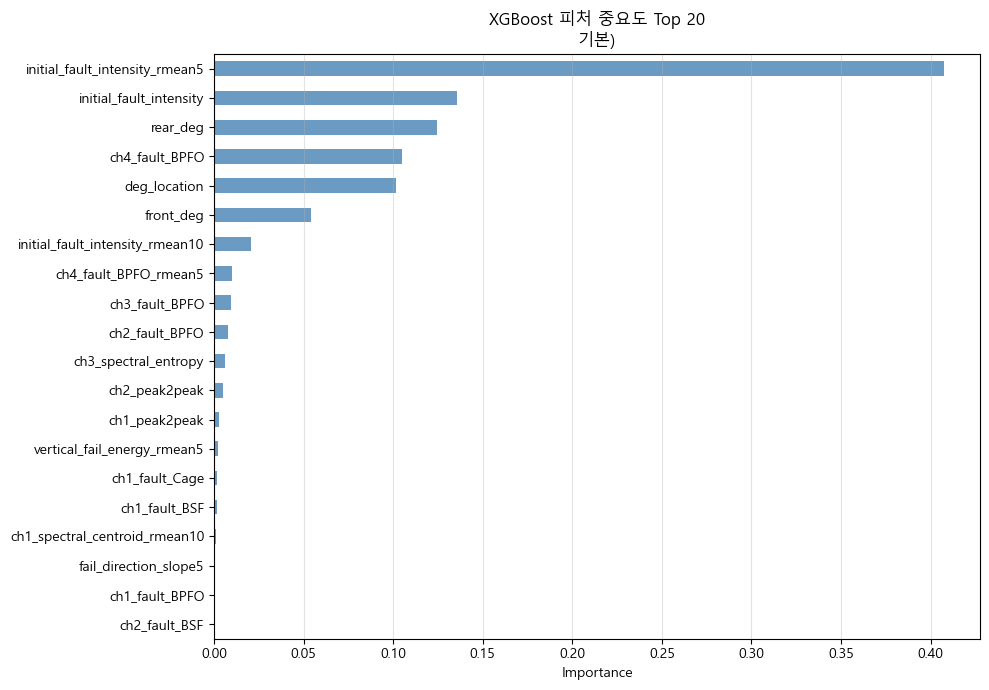

In [9]:
# ============================================================
# 피처 중요도 확인
# ============================================================
importance = pd.Series(
    model.feature_importances_,
    index=feat_cols
).sort_values(ascending=False)

# ch2 파생 피처 중요도
ch2_feat_cols = [c for c in feat_cols if 'ch2_fault' in c]
ch2_imp       = importance[ch2_feat_cols].sum()
total_imp     = importance.sum()

print(f'\n=== 피처 중요도 ===')
print(f'ch2_fault 피처 중요도 합계: {ch2_imp:.4f} ({ch2_imp/total_imp*100:.1f}%)')
print('\n상위 15개:')
print(importance.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('XGBoost 피처 중요도 Top 20\n기본)')
ax.set_xlabel('Importance')
ax.grid(True, axis='x', alpha=0.35)
plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/feature_importance_기본.png', bbox_inches='tight')
plt.show()

In [ ]:
# # ============================================================
# # 최종 모델 학습 + Test 예측 + 제출 파일
# # ============================================================
# fix_seed()
# final_model = XGBRegressor(**XGB_PARAMS)
# df_final    = make_cutoff_samples(df_feat, TRAIN_CUTOFFS + VALID_CUTOFFS)
# final_model.fit(
#     df_final[feat_cols].values.astype(np.float32),
#     df_final['ttf'].values.astype(np.float32),
#     sample_weight=calc_sample_weights(df_final['cutoff'].values)
# )

# df_test = load_test_data()
# if df_test is not None:
#     # Test 데이터에도 동일 파생 피처 추가
#     df_test['ch2_fault_total'] = (
#         df_test[ch2_fault_cols].sum(axis=1).astype(np.float32)
#     )
#     df_test['ch2_ch1_fault_ratio'] = (
#         df_test[ch2_fault_cols].sum(axis=1) /
#         (df_test[ch1_fault_cols].sum(axis=1) + 1e-10)
#     ).astype(np.float32)

#     df_test = add_trend_features(df_test, windows=[5, 10],
#                                   group_col='test_id')
#     df_test = df_test.copy().fillna(0)

#     results = []
#     for tid in sorted(df_test['test_id'].unique()):
#         df_t     = df_test[df_test['test_id'] == tid]
#         last_row = df_t.loc[df_t['t_abs'].idxmax()]

#         feat_vals = np.array([
#             last_row[c] if c in last_row.index else 0.0
#             for c in feat_cols
#         ]).reshape(1, -1).astype(np.float32)

#         pred_ttf_val = float(final_model.predict(feat_vals)[0])
#         pred_rul     = max(pred_ttf_val - float(last_row['t_abs']), 0)

#         results.append({'File': f'Test{tid}',
#                          'RUL_Score': round(pred_rul, 2)})
#         print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

#     result_df = pd.DataFrame(results)
#     result_df.to_excel('../output/best_model_ch2fault_submission.xlsx',
#                        index=False)
#     print('\n=== 제출 파일 ===')
#     print(result_df.to_string(index=False))

## ttf + ln(RUL) <- 말기, Train3에서 소폭 상승

In [22]:
# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
print(f'피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

# ── 두 모델 학습 ─────────────────────────────────────────────
# Model G: TTF 예측
fix_seed()
model_ttf = XGBRegressor(**XGB_PARAMS)
model_ttf.fit(X_train,
              df_train_s['ttf'].values.astype(np.float32),
              sample_weight=weights)

# ln(RUL) 모델
fix_seed()
model_log = XGBRegressor(**XGB_PARAMS)
model_log.fit(X_train,
              np.log1p(df_train_s['RUL'].values).astype(np.float32),
              sample_weight=weights)

print('두 모델 학습 완료')

# ── Valid 예측 ────────────────────────────────────────────────
pred_ttf_valid = model_ttf.predict(X_valid).astype(np.float32)
pred_log_valid = model_log.predict(X_valid).astype(np.float32)

rul_ttf_valid = np.maximum(
    pred_ttf_valid - df_valid_s['t_abs'].values, 0)
rul_log_valid = np.maximum(
    np.expm1(pred_log_valid), 0)

act_rul_arr = df_valid_s['RUL'].values

# ── α별 성능 확인 (Valid) ─────────────────────────────────────
print('\n=== α별 Valid 성능 ===')
print(f'{"α":>6} | {"전체":>8} | {"T1":>8} | '
      f'{"T2":>8} | {"T3":>8} | {"T4":>8} | '
      f'{"co20%":>8} | {"co50%":>8} | {"co80%":>8}')
print('-' * 85)

alpha_valid_results = {}

for alpha in np.arange(0.0, 1.05, 0.1):
    alpha    = round(float(alpha), 1)
    pred_rul = alpha * rul_log_valid + (1 - alpha) * rul_ttf_valid
    scores   = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul)]
    avg      = float(np.mean(scores))

    # Train별
    t_scores = {}
    for t in [1, 2, 3, 4]:
        mask        = df_valid_s['train_id'].values == t
        t_scores[t] = float(np.mean(
            [scores[i] for i in range(len(scores)) if mask[i]]))

    # cutoff별
    co_scores = {}
    for co in VALID_CUTOFFS:
        mask       = df_valid_s['cutoff'].values == co
        co_scores[co] = float(np.mean(
            [scores[i] for i in range(len(scores)) if mask[i]]))

    alpha_valid_results[alpha] = {
        'avg': avg, 't_scores': t_scores, 'co_scores': co_scores}

    print(f'{alpha:>6.1f} | {avg:>8.4f} | {t_scores[1]:>8.4f} | '
          f'{t_scores[2]:>8.4f} | {t_scores[3]:>8.4f} | {t_scores[4]:>8.4f} | '
          f'{co_scores[0.2]:>8.4f} | {co_scores[0.5]:>8.4f} | '
          f'{co_scores[0.8]:>8.4f}')

# ── α별 LOO 검증 ─────────────────────────────────────────────
print('\n=== α별 LOO + 균형점수 ===')
print(f'{"α":>6} | {"균형점수":>10} | {"LOO평균":>8} | '
      f'{"LOO_T3":>8} | {"Valid":>8}')
print('-' * 55)

alpha_results = {}
best_alpha    = 0.0
best_balanced = -1

for alpha in np.arange(0.0, 1.05, 0.1):
    alpha      = round(float(alpha), 1)
    valid_avg  = alpha_valid_results[alpha]['avg']
    loo_scores = []
    loo_per_train = {}

    for val_id in [1, 2, 3, 4]:
        train_ids    = [t for t in [1,2,3,4] if t != val_id]
        df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
        df_valid_loo = df_feat[df_feat['train_id'] == val_id]

        df_tr_s = make_cutoff_samples(
            df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
        df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

        X_tr = df_tr_s[feat_cols].values.astype(np.float32)
        X_va = df_va_s[feat_cols].values.astype(np.float32)
        w_tr = calc_sample_weights(df_tr_s['cutoff'].values)

        fix_seed()
        m_ttf = XGBRegressor(**XGB_PARAMS)
        m_ttf.fit(X_tr,
                  df_tr_s['ttf'].values.astype(np.float32),
                  sample_weight=w_tr)

        fix_seed()
        m_log = XGBRegressor(**XGB_PARAMS)
        m_log.fit(X_tr,
                  np.log1p(df_tr_s['RUL'].values).astype(np.float32),
                  sample_weight=w_tr)

        rul_ttf_loo = np.maximum(
            m_ttf.predict(X_va).astype(np.float32) -
            df_va_s['t_abs'].values, 0)
        rul_log_loo = np.maximum(
            np.expm1(m_log.predict(X_va).astype(np.float32)), 0)

        pred_rul_loo = alpha * rul_log_loo + (1 - alpha) * rul_ttf_loo
        act_rul_loo  = df_va_s['RUL'].values
        scores_loo   = [calc_score(a, p)
                        for a, p in zip(act_rul_loo, pred_rul_loo)]
        avg_loo      = float(np.mean(scores_loo))

        loo_scores.append(avg_loo)
        loo_per_train[val_id] = avg_loo

    loo_avg    = float(np.mean(loo_scores))
    train3_loo = loo_per_train[3]

    balanced = (0.3 * loo_avg +
                0.3 * train3_loo +
                0.4 * valid_avg)

    alpha_results[alpha] = {
        'loo_avg':    loo_avg,
        'train3_loo': train3_loo,
        'valid_avg':  valid_avg,
        'balanced':   balanced,
    }

    print(f'{alpha:>6.1f} | {balanced:>10.4f} | {loo_avg:>8.4f} | '
          f'{train3_loo:>8.4f} | {valid_avg:>8.4f}')

    if balanced > best_balanced:
        best_balanced = balanced
        best_alpha    = alpha

print(f'\n=== 최적 α: {best_alpha} ===')
print(f'  균형 점수:   {alpha_results[best_alpha]["balanced"]:.4f}')
print(f'  LOO 평균:   {alpha_results[best_alpha]["loo_avg"]:.4f}')
print(f'  Train3 LOO: {alpha_results[best_alpha]["train3_loo"]:.4f}')
print(f'  Valid 평균: {alpha_results[best_alpha]["valid_avg"]:.4f}')


피처 수: 206개
Train 샘플: 24개 | Valid 샘플: 12개
두 모델 학습 완료

=== α별 Valid 성능 ===
     α |       전체 |       T1 |       T2 |       T3 |       T4 |    co20% |    co50% |    co80%
-------------------------------------------------------------------------------------
   0.0 |   0.8484 |   0.7607 |   0.9637 |   0.7512 |   0.9179 |   0.9808 |   0.9262 |   0.6381
   0.1 |   0.8163 |   0.7332 |   0.9431 |   0.6538 |   0.9350 |   0.9437 |   0.8948 |   0.6104
   0.2 |   0.7501 |   0.7084 |   0.8865 |   0.5878 |   0.8177 |   0.8866 |   0.8591 |   0.5046
   0.3 |   0.6904 |   0.6859 |   0.8343 |   0.5405 |   0.7009 |   0.8335 |   0.8257 |   0.4120
   0.4 |   0.6432 |   0.6655 |   0.7861 |   0.5043 |   0.6167 |   0.7839 |   0.7944 |   0.3512
   0.5 |   0.6044 |   0.6469 |   0.7418 |   0.4751 |   0.5538 |   0.7377 |   0.7651 |   0.3104
   0.6 |   0.5715 |   0.6298 |   0.7008 |   0.4503 |   0.5051 |   0.6945 |   0.7376 |   0.2823
   0.7 |   0.5428 |   0.6141 |   0.6630 |   0.4285 |   0.4658 |   0.6542 |   0.71

In [23]:
df_final = make_cutoff_samples(df_feat, TRAIN_CUTOFFS + VALID_CUTOFFS)
X_final  = df_final[feat_cols].values.astype(np.float32)
w_final  = calc_sample_weights(df_final['cutoff'].values)

final_ttf = XGBRegressor(**XGB_PARAMS)
fix_seed()
final_ttf.fit(X_final,
              df_final['ttf'].values.astype(np.float32),
              sample_weight=w_final)

final_log = XGBRegressor(**XGB_PARAMS)
fix_seed()
final_log.fit(X_final,
              np.log1p(df_final['RUL'].values).astype(np.float32),
              sample_weight=w_final)

df_test = load_test_data()
if df_test is not None:
    df_test = add_trend_features(df_test, windows=[5, 10],
                                  group_col='test_id')
    df_test = df_test.copy().fillna(0)

    results = []
    for tid in sorted(df_test['test_id'].unique()):
        df_t     = df_test[df_test['test_id'] == tid]
        last_row = df_t.loc[df_t['t_abs'].idxmax()]
        t_abs    = float(last_row['t_abs'])

        feat_vals = np.array([
            last_row[c] if c in last_row.index else 0.0
            for c in feat_cols
        ]).reshape(1, -1).astype(np.float32)

        rul_from_ttf = max(
            float(final_ttf.predict(feat_vals)[0]) - t_abs, 0)
        rul_from_log = max(
            float(np.expm1(final_log.predict(feat_vals)[0])), 0)
        pred_rul     = (best_alpha * rul_from_log +
                       (1 - best_alpha) * rul_from_ttf)

        results.append({'File': f'Test{tid}',
                         'RUL_Score': round(pred_rul, 2)})
        print(f'Test{tid} | ttf={rul_from_ttf:.0f}s | '
              f'log={rul_from_log:.0f}s | '
              f'앙상블={pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

    pd.DataFrame(results).to_excel(
        '../output/ensemble_log_submission.xlsx', index=False)
    print('\n=== 제출 파일 ===')
    print(pd.DataFrame(results).to_string(index=False))

Test1 | ttf=34895s | log=40874s | 앙상블=37885s (10.52h)
Test2 | ttf=28467s | log=16235s | 앙상블=22351s (6.21h)
Test3 | ttf=29250s | log=28130s | 앙상블=28690s (7.97h)
Test4 | ttf=27963s | log=16075s | 앙상블=22019s (6.12h)
Test5 | ttf=28248s | log=12835s | 앙상블=20541s (5.71h)
Test6 | ttf=38487s | log=10997s | 앙상블=24742s (6.87h)

=== 제출 파일 ===
 File  RUL_Score
Test1   37884.73
Test2   22351.04
Test3   28690.04
Test4   22019.04
Test5   20541.26
Test6   24741.96


## 타겟 변환 = y = RUL / max(t_abs)

In [7]:
# ============================================================
# 타겟 변환: y = RUL / max(t_abs)
# 역변환: pred_RUL = pred × max_t_abs (불확실성 없음)
# XGBoost + sample_weight (말기 가중)
# ============================================================

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

# Train별 max(t_abs) 계산 (고정 상수)
max_tabs = df_feat.groupby('train_id')['t_abs'].max()
print('=== Train별 max(t_abs) ===')
for t, v in max_tabs.items():
    print(f'  Train{t}: {v:.0f}s ({v/3600:.2f}h)')

# make_cutoff_samples 시 max_t_abs 컬럼 추가
def make_cutoff_samples_with_maxt(df, cutoffs, max_tabs):
    samples = []
    for tid in df['train_id'].unique():
        df_t     = df[df['train_id'] == tid].copy()
        ttf      = float(df_t['ttf'].iloc[0])
        max_t    = float(max_tabs[tid])

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue

            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                'max_t_abs': max_t,
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)


df_train_s = make_cutoff_samples_with_maxt(df_feat, TRAIN_CUTOFFS, max_tabs)
df_valid_s = make_cutoff_samples_with_maxt(df_feat, VALID_CUTOFFS, max_tabs)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL',
                          't_abs', 'max_t_abs']]
print(f'\n피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

# ── 타겟: RUL / max(t_abs) ───────────────────────────────────
# max(t_abs)는 각 Train의 마지막 시점 (고정 상수)
# 역변환: pred_RUL = pred × max_t_abs
#   Test max_t_abs = 29,459s (알고 있음) → 불확실성 없음
y_train = (df_train_s['RUL'] /
           df_train_s['max_t_abs']).astype(np.float32)
y_valid = (df_valid_s['RUL'] /
           df_valid_s['max_t_abs']).astype(np.float32)

print(f'\n타겟 분포 (RUL/max_t_abs):')
for t in [1, 2, 3, 4]:
    mask = df_train_s['train_id'] == t
    print(f'  Train{t} | min={y_train[mask].min():.3f} '
          f'| max={y_train[mask].max():.3f} '
          f'| mean={y_train[mask].mean():.3f}')

# ── 학습 ─────────────────────────────────────────────────────
X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train.values, sample_weight=weights)
print('\n학습 완료')

# ── Valid 평가 ────────────────────────────────────────────────
pred_ratio   = np.clip(
    model.predict(X_valid).astype(np.float32), 0, None)
pred_rul_arr = np.maximum(
    pred_ratio * df_valid_s['max_t_abs'].values, 0).astype(np.float32)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== 타겟 변환 (y=RUL/max_t_abs): XGBoost + sample_weight ===')
for co in VALID_CUTOFFS:
    mask   = df_valid_s['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
    df_co = df_valid_s[mask].reset_index(drop=True)
    p_co  = pred_rul_arr[mask]
    for i, row in df_co.iterrows():
        s = calc_score(row['RUL'], p_co[i])
        print(f'    Train{int(row["train_id"])} | '
              f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  기존 Best Score: 0.8783')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8783 else "❌ 미개선"}')

# ── LOO 검증 ─────────────────────────────────────────────────
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples_with_maxt(
        df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS, max_tabs)
    df_va_s = make_cutoff_samples_with_maxt(
        df_valid_loo, VALID_CUTOFFS, max_tabs)

    y_tr = (df_tr_s['RUL'] /
            df_tr_s['max_t_abs']).astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(df_tr_s[feat_cols].values.astype(np.float32),
          y_tr.values,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_ratio_loo = np.clip(
        m.predict(df_va_s[feat_cols].values.astype(np.float32))
        .astype(np.float32), 0, None)
    pred_rul_loo   = np.maximum(
        pred_ratio_loo * df_va_s['max_t_abs'].values, 0)
    act_rul_loo    = df_va_s['RUL'].values
    scores_loo     = [calc_score(a, p)
                      for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg    = np.mean([r['score'] for r in loo_results])
train3_loo = [r['score'] for r in loo_results if r['val_id'] == 3][0]
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} (기존: 0.4365) ===')
print(f'=== Train3 LOO:    {train3_loo:.4f} (기존: 0.1168) ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4365 else "❌ 미개선"} ===')

=== Train별 max(t_abs) ===
  Train1: 75060s (20.85h)
  Train2: 67860s (18.85h)
  Train3: 52860s (14.68h)
  Train4: 81660s (22.68h)

피처 수: 191개
Train 샘플: 24개 | Valid 샘플: 12개

타겟 분포 (RUL/max_t_abs):
  Train1 | min=0.106 | max=0.906 | mean=0.505
  Train2 | min=0.108 | max=0.904 | mean=0.506
  Train3 | min=0.109 | max=0.915 | mean=0.508
  Train4 | min=0.107 | max=0.915 | mean=0.509

학습 완료

=== 타겟 변환 (y=RUL/max_t_abs): XGBoost + sample_weight ===
  cutoff=20% | Score=0.5798 | MAE=22268s
    Train1 | 실제=60202s | 예측=48036s | Score=0.7557
    Train2 | 실제=54720s | 예측=27544s | Score=0.5023
    Train3 | 실제=42966s | 예측=22849s | Score=0.5225
    Train4 | 실제=66354s | 예측=36738s | Score=0.5386
  cutoff=50% | Score=0.8633 | MAE=4155s
    Train1 | 실제=37992s | 예측=37388s | Score=0.9782
    Train2 | 실제=34320s | 예측=34261s | Score=0.9977
    Train3 | 실제=26766s | 예측=27873s | Score=0.8664
    Train4 | 실제=41754s | 예측=26905s | Score=0.6108
  cutoff=80% | Score=0.0257 | MAE=16552s
    Train1 | 실제=15192s | 예측=35368

## 타겟 변환 y= t_abs/ttf

In [8]:
# ============================================================
# 타겟 변환: y = t_abs / ttf (수명 진행률)
# 역변환: pred_RUL = t_abs × (1/pred - 1)
# y_pred = t_abs/ttf
# ttf  = t_abs / y_pred
# RUL  = ttf - t_abs = t_abs/y_pred - t_abs = t_abs × (1/y_pred - 1)
# ============================================================

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
print(f'피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

# ── 타겟: t_abs / ttf (수명 진행률 0~1) ──────────────────────
# 역변환: pred_RUL = t_abs × (1/pred - 1)
# t_abs는 Test에서 알고 있음 → 불확실성 없음
y_train = (df_train_s['t_abs'] /
           df_train_s['ttf']).astype(np.float32)
y_valid = (df_valid_s['t_abs'] /
           df_valid_s['ttf']).astype(np.float32)

print(f'\n타겟 분포 (t_abs/ttf):')
for t in [1, 2, 3, 4]:
    mask = df_train_s['train_id'] == t
    print(f'  Train{t} | min={y_train[mask].min():.3f} '
          f'| max={y_train[mask].max():.3f} '
          f'| mean={y_train[mask].mean():.3f}')

# ── 학습 ─────────────────────────────────────────────────────
X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train.values, sample_weight=weights)
print('\n학습 완료')

# ── Valid 평가 ────────────────────────────────────────────────
# pred = t_abs/ttf → ttf = t_abs/pred → RUL = ttf - t_abs
pred_ratio   = np.clip(
    model.predict(X_valid).astype(np.float32), 1e-6, 1.0)
pred_rul_arr = np.maximum(
    df_valid_s['t_abs'].values * (1/pred_ratio - 1), 0
).astype(np.float32)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== 타겟 변환 (y=t_abs/ttf): XGBoost + sample_weight ===')
for co in VALID_CUTOFFS:
    mask   = df_valid_s['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
    df_co = df_valid_s[mask].reset_index(drop=True)
    p_co  = pred_rul_arr[mask]
    for i, row in df_co.iterrows():
        s = calc_score(row['RUL'], p_co[i])
        print(f'    Train{int(row["train_id"])} | '
              f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  기존 Best Score: 0.8783')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8783 else "❌ 미개선"}')

# ── LOO 검증 ─────────────────────────────────────────────────
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    y_tr = (df_tr_s['t_abs'] /
            df_tr_s['ttf']).astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(df_tr_s[feat_cols].values.astype(np.float32),
          y_tr.values,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_ratio_loo = np.clip(
        m.predict(df_va_s[feat_cols].values.astype(np.float32))
        .astype(np.float32), 1e-6, 1.0)
    pred_rul_loo   = np.maximum(
        df_va_s['t_abs'].values * (1/pred_ratio_loo - 1), 0)
    act_rul_loo    = df_va_s['RUL'].values
    scores_loo     = [calc_score(a, p)
                      for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg    = np.mean([r['score'] for r in loo_results])
train3_loo = [r['score'] for r in loo_results if r['val_id'] == 3][0]
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} (기존: 0.4365) ===')
print(f'=== Train3 LOO:    {train3_loo:.4f} (기존: 0.1168) ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4365 else "❌ 미개선"} ===')

피처 수: 191개
Train 샘플: 24개 | Valid 샘플: 12개

타겟 분포 (t_abs/ttf):
  Train1 | min=0.096 | max=0.894 | mean=0.496
  Train2 | min=0.098 | max=0.892 | mean=0.495
  Train3 | min=0.091 | max=0.892 | mean=0.495
  Train4 | min=0.095 | max=0.894 | mean=0.497

학습 완료

=== 타겟 변환 (y=t_abs/ttf): XGBoost + sample_weight ===
  cutoff=20% | Score=0.3550 | MAE=42146s
    Train1 | 실제=60202s | 예측=27124s | Score=0.4669
    Train2 | 실제=54720s | 예측=8586s | Score=0.3108
    Train3 | 실제=42966s | 예측=7375s | Score=0.3172
    Train4 | 실제=66354s | 예측=12571s | Score=0.3251
  cutoff=50% | Score=0.7946 | MAE=6700s
    Train1 | 실제=37992s | 예측=37780s | Score=0.9923
    Train2 | 실제=34320s | 예측=32266s | Score=0.9204
    Train3 | 실제=26766s | 예측=28525s | Score=0.7962
    Train4 | 실제=41754s | 예측=18979s | Score=0.4695
  cutoff=80% | Score=0.0043 | MAE=30918s
    Train1 | 실제=15192s | 예측=54278s | Score=0.0001
    Train2 | 실제=13920s | 예측=30825s | Score=0.0149
    Train3 | 실제=11166s | 예측=49429s | Score=0.0000
    Train4 | 실제=16554s |

## 타겟 변환 y= RUL/ttf

In [5]:
# ============================================================
# 타겟 변환: y = RUL / TTF (잔여 수명 비율)
# XGBoost + sample_weight (말기 가중)
# ============================================================

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
print(f'피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

# ── 타겟: RUL / TTF (0~1 비율) ───────────────────────────────
# RUL/TTF = 1 - (t_abs/TTF) = 남은 수명 비율
# Train3 TTF=53,225 / Train4 TTF=82,613 → 절댓값 차이 제거
y_train_ratio = (df_train_s['RUL'] / df_train_s['ttf']).astype(np.float32)
y_valid_ratio = (df_valid_s['RUL'] / df_valid_s['ttf']).astype(np.float32)

print(f'\n타겟 분포 (RUL/TTF):')
for t in [1, 2, 3, 4]:
    mask = df_train_s['train_id'] == t
    print(f'  Train{t} | min={y_train_ratio[mask].min():.3f} '
          f'| max={y_train_ratio[mask].max():.3f} '
          f'| mean={y_train_ratio[mask].mean():.3f}')

# ── 학습 ─────────────────────────────────────────────────────
X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train_ratio.values, sample_weight=weights)
print('\n학습 완료')

# ── Valid 평가 ────────────────────────────────────────────────
# 예측: ratio → RUL 역변환
# pred_RUL = pred_ratio × TTF
pred_ratio   = model.predict(X_valid).astype(np.float32)
pred_ratio   = np.clip(pred_ratio, 0, 1)  # 0~1 범위 제한
pred_rul_arr = np.maximum(
    pred_ratio * df_valid_s['ttf'].values, 0
).astype(np.float32)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== 타겟 변환 (y=RUL/TTF): XGBoost + sample_weight ===')
for co in VALID_CUTOFFS:
    mask   = df_valid_s['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
    df_co = df_valid_s[mask].reset_index(drop=True)
    p_co  = pred_rul_arr[mask]
    for i, row in df_co.iterrows():
        s = calc_score(row['RUL'], p_co[i])
        print(f'    Train{int(row["train_id"])} | '
              f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  기존 Best Score: 0.8783')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8783 else "❌ 미개선"}')

# ── LOO 검증 ─────────────────────────────────────────────────
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    y_tr = (df_tr_s['RUL'] / df_tr_s['ttf']).astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(df_tr_s[feat_cols].values.astype(np.float32),
          y_tr.values,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_ratio_loo = np.clip(
        m.predict(df_va_s[feat_cols].values.astype(np.float32)), 0, 1)
    pred_rul_loo   = np.maximum(
        pred_ratio_loo * df_va_s['ttf'].values, 0)
    act_rul_loo    = df_va_s['RUL'].values
    scores_loo     = [calc_score(a, p)
                      for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg = np.mean([r['score'] for r in loo_results])
train3_loo = [r['score'] for r in loo_results if r['val_id'] == 3][0]
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} (기존: 0.4365) ===')
print(f'=== Train3 LOO:    {train3_loo:.4f} (기존: 0.1168) ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4365 else "❌ 미개선"} ===')

피처 수: 191개
Train 샘플: 24개 | Valid 샘플: 12개

타겟 분포 (RUL/TTF):
  Train1 | min=0.106 | max=0.904 | mean=0.504
  Train2 | min=0.108 | max=0.902 | mean=0.505
  Train3 | min=0.108 | max=0.909 | mean=0.505
  Train4 | min=0.106 | max=0.905 | mean=0.503

학습 완료

=== 타겟 변환 (y=RUL/TTF): XGBoost + sample_weight ===
  cutoff=20% | Score=0.5737 | MAE=22748s
    Train1 | 실제=60202s | 예측=48295s | Score=0.7602
    Train2 | 실제=54720s | 예측=26694s | Score=0.4916
    Train3 | 실제=42966s | 예측=22271s | Score=0.5129
    Train4 | 실제=66354s | 예측=35988s | Score=0.5302
  cutoff=50% | Score=0.8579 | MAE=4438s
    Train1 | 실제=37992s | 예측=37670s | Score=0.9883
    Train2 | 실제=34320s | 예측=33371s | Score=0.9624
    Train3 | 실제=26766s | 예측=27723s | Score=0.8834
    Train4 | 실제=41754s | 예측=26231s | Score=0.5973
  cutoff=80% | Score=0.0270 | MAE=16565s
    Train1 | 실제=15192s | 예측=35677s | Score=0.0093
    Train2 | 실제=13920s | 예측=24703s | Score=0.0682
    Train3 | 실제=11166s | 예측=28750s | Score=0.0043
    Train4 | 실제=16554s | 예

## 타겟 변환 y=ln(RUL)

In [10]:
# ============================================================
# 타겟 변환: y = log1p(RUL)
# 역변환: pred_RUL = expm1(pred)
# XGBoost + sample_weight (말기 가중)
# ============================================================

XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
VALID_CUTOFFS = [0.2, 0.5, 0.8]
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']

# ── 데이터 로드 ───────────────────────────────────────────────
df_raw  = load_train_data()
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]
print(f'피처 수: {len(feat_cols)}개')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

# ── 타겟: log1p(RUL) ─────────────────────────────────────────
# log 변환으로 Train별 RUL 스케일 차이 완화
# Train3: log1p(53225)=10.88 / Train4: log1p(82613)=11.32
# → 절댓값 차이 82613-53225=29388 → log 후 11.32-10.88=0.44
# 역변환: expm1(pred) → TTF 필요 없음 ✅ 불확실성 없음 ✅
y_train = np.log1p(df_train_s['RUL'].values).astype(np.float32)
y_valid = np.log1p(df_valid_s['RUL'].values).astype(np.float32)

print(f'\n타겟 분포 (log1p(RUL)):')
for t in [1, 2, 3, 4]:
    mask = df_train_s['train_id'] == t
    print(f'  Train{t} | min={y_train[mask].min():.3f} '
          f'| max={y_train[mask].max():.3f} '
          f'| mean={y_train[mask].mean():.3f}')

# ── 학습 ─────────────────────────────────────────────────────
X_train = df_train_s[feat_cols].values.astype(np.float32)
X_valid = df_valid_s[feat_cols].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, sample_weight=weights)
print('\n학습 완료')

# ── Valid 평가 ────────────────────────────────────────────────
pred_log     = model.predict(X_valid).astype(np.float32)
pred_rul_arr = np.maximum(np.expm1(pred_log), 0).astype(np.float32)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== 타겟 변환 (y=log1p(RUL)): XGBoost + sample_weight ===')
for co in VALID_CUTOFFS:
    mask   = df_valid_s['cutoff'].values == co
    s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
    mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
    print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
    df_co = df_valid_s[mask].reset_index(drop=True)
    p_co  = pred_rul_arr[mask]
    for i, row in df_co.iterrows():
        s = calc_score(row['RUL'], p_co[i])
        print(f'    Train{int(row["train_id"])} | '
              f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  기존 Best Score: 0.8783')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8783 else "❌ 미개선"}')

# ── LOO 검증 ─────────────────────────────────────────────────
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    y_tr = np.log1p(df_tr_s['RUL'].values).astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(df_tr_s[feat_cols].values.astype(np.float32),
          y_tr,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_log_loo = m.predict(
        df_va_s[feat_cols].values.astype(np.float32)).astype(np.float32)
    pred_rul_loo = np.maximum(np.expm1(pred_log_loo), 0)
    act_rul_loo  = df_va_s['RUL'].values
    scores_loo   = [calc_score(a, p)
                    for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg    = np.mean([r['score'] for r in loo_results])
train3_loo = [r['score'] for r in loo_results if r['val_id'] == 3][0]
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} (기존: 0.4365) ===')
print(f'=== Train3 LOO:    {train3_loo:.4f} (기존: 0.1168) ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4365 else "❌ 미개선"} ===')

피처 수: 191개
Train 샘플: 24개 | Valid 샘플: 12개

타겟 분포 (log1p(RUL)):
  Train1 | min=8.986 | max=11.127 | mean=10.345
  Train2 | min=8.898 | max=11.024 | mean=10.247
  Train3 | min=8.660 | max=10.787 | mean=10.001
  Train4 | min=9.077 | max=11.222 | mean=10.436

학습 완료

=== 타겟 변환 (y=log1p(RUL)): XGBoost + sample_weight ===
  cutoff=20% | Score=0.5158 | MAE=26970s
    Train1 | 실제=60202s | 예측=43000s | Score=0.6729
    Train2 | 실제=54720s | 예측=18302s | Score=0.3975
    Train3 | 실제=42966s | 예측=19083s | Score=0.4627
    Train4 | 실제=66354s | 예측=35974s | Score=0.5301
  cutoff=50% | Score=0.5915 | MAE=9652s
    Train1 | 실제=37992s | 예측=35374s | Score=0.9089
    Train2 | 실제=34320s | 예측=41423s | Score=0.4880
    Train3 | 실제=26766s | 예측=31898s | Score=0.5145
    Train4 | 실제=41754s | 예측=17999s | Score=0.4544
  cutoff=80% | Score=0.2677 | MAE=11762s
    Train1 | 실제=15192s | 예측=25453s | Score=0.0962
    Train2 | 실제=13920s | 예측=12975s | Score=0.9102
    Train3 | 실제=11166s | 예측=33830s | Score=0.0009
    Train4 |

### front_axial_top10, front_axial_std 추가


=== 피처 중요도 ===
ch2_fault 피처 중요도 합계: 0.0586 (5.9%)

상위 15개:
front_axial_std                    0.224011
initial_fault_intensity_rmean5     0.160241
initial_fault_intensity            0.122413
rear_deg                           0.098484
ch4_fault_BPFO                     0.080157
initial_fault_intensity_rmean10    0.076183
ch2_fault_BSF                      0.056792
deg_location                       0.052532
front_deg                          0.045509
ch3_fault_BPFO                     0.019226
ch4_fault_BPFO_rmean5              0.018945
front_axial_top10                  0.018100
ch2_peak2peak                      0.006862
ch2_spectral_centroid              0.005459
ch3_spectral_entropy               0.003346


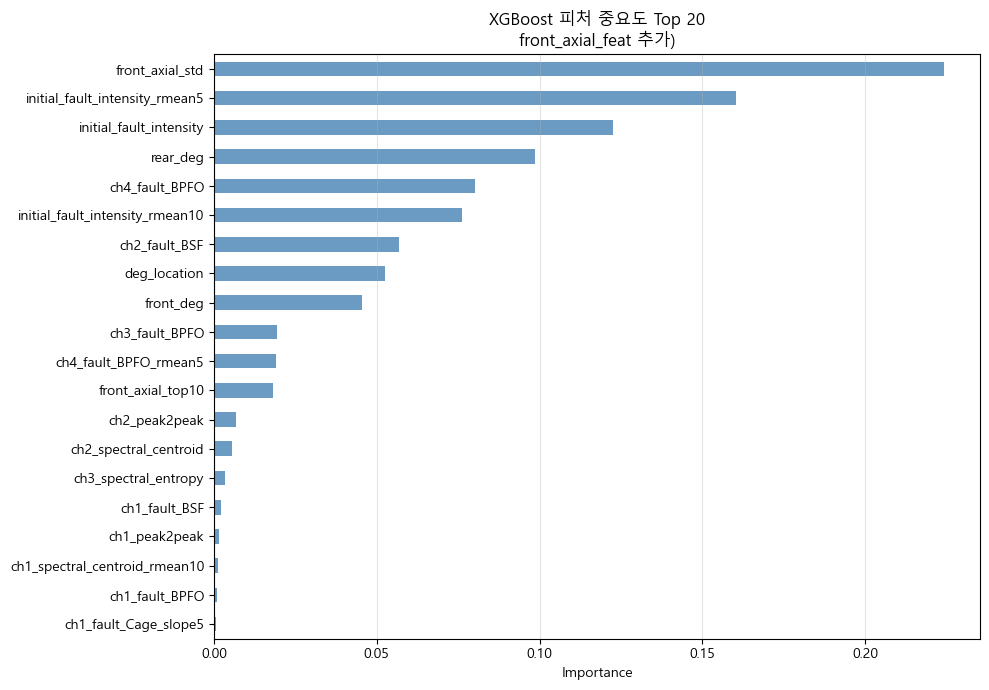

In [5]:
# ============================================================
# 피처 중요도 확인
# ============================================================
importance = pd.Series(
    model.feature_importances_,
    index=feat_cols
).sort_values(ascending=False)

# ch2 파생 피처 중요도
ch2_feat_cols = [c for c in feat_cols if 'ch2_fault' in c]
ch2_imp       = importance[ch2_feat_cols].sum()
total_imp     = importance.sum()

print(f'\n=== 피처 중요도 ===')
print(f'ch2_fault 피처 중요도 합계: {ch2_imp:.4f} ({ch2_imp/total_imp*100:.1f}%)')
print('\n상위 15개:')
print(importance.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('XGBoost 피처 중요도 Top 20\nfront_axial_feat 추가)')
ax.set_xlabel('Importance')
ax.grid(True, axis='x', alpha=0.35)
plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/feature_importance_front_axial_feat.png', bbox_inches='tight')
plt.show()

### fault에 가중치

In [ ]:
# ── 전역 상수 ─────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
)

TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]  # 학습 cutoff
VALID_CUTOFFS = [0.2, 0.5, 0.8]                   # 검증 cutoff
EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
                 'rpm', 'train_id', 'test_id']
FAULT_TYPES   = ['BPFI', 'BPFO', 'BSF', 'Cage']

# ============================================================
# 함수 정의
# ============================================================

# ── 샘플 가중치: 말기 cutoff에 높은 가중치 ───────────────────
def calc_sample_weights(cutoff_values):
    """
    cutoff^2 가중치: 말기(0.9)에 높은 가중치, 초반(0.1)에 낮은 가중치
    TTF 예측 시 말기 열화 패턴 학습 강화
    """
    co = np.array(cutoff_values, dtype=np.float32)
    w  = co ** 2
    return (w / w.mean()).astype(np.float32)


# ── cutoff 기반 샘플 생성 ─────────────────────────────────────
def make_cutoff_samples(df, cutoffs):
    """
    각 Train × 각 cutoff 시점까지의 데이터 →
    마지막 행(1초) 피처 + 해당 시점 TTF/RUL 반환
    """
    samples = []
    for tid in df['train_id'].unique():
        df_t = df[df['train_id'] == tid].copy()
        ttf  = float(df_t['ttf'].iloc[0])

        for co in cutoffs:
            cutoff_t = ttf * co
            df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
            if len(df_cut) == 0:
                continue

            last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
            rul      = float(ttf - last_row['t_abs'])
            samples.append({
                'train_id': tid,
                'cutoff':   co,
                'ttf':      ttf,
                'RUL':      rul,
                't_abs':    float(last_row['t_abs']),
                **{c: last_row[c] for c in df_cut.columns
                   if c not in EXCLUDE_COLS + ['train_id']}
            })
    return pd.DataFrame(samples)


# ── Valid 결과 출력 ───────────────────────────────────────────
def print_valid_results(df_valid_s, pred_rul_arr, act_rul_arr,
                        scores, valid_cutoffs):
    for co in valid_cutoffs:
        mask   = df_valid_s['cutoff'].values == co
        s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
        mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

        df_co = df_valid_s[mask].reset_index(drop=True)
        p_co  = pred_rul_arr[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

In [ ]:
# ============================================================
# 데이터 로드 및 trend 피처 추가
# ============================================================
df_raw = load_train_data()

# 트렌드 피처 추가 (ch2_fault_total_slope5 등 자동 생성)
df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
df_feat = df_feat.copy().fillna(0)

# cutoff 샘플 생성
df_train_s = make_cutoff_samples(df_feat, TRAIN_CUTOFFS)
df_valid_s = make_cutoff_samples(df_feat, VALID_CUTOFFS)

feat_cols = [c for c in df_train_s.columns
             if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

print(f'피처 수: {len(feat_cols)}개')
print(f'  - ch2_fault_total 포함: {"ch2_fault_total" in feat_cols}')
print(f'  - ch2_ch1_fault_ratio 포함: {"ch2_ch1_fault_ratio" in feat_cols}')
print(f'Train 샘플: {len(df_train_s)}개 | Valid 샘플: {len(df_valid_s)}개')

피처 수: 206개
  - ch2_fault_total 포함: True
  - ch2_ch1_fault_ratio 포함: True
Train 샘플: 24개 | Valid 샘플: 12개


In [ ]:
# ============================================================
# 모델 학습
# ============================================================
X_train = df_train_s[feat_cols].values.astype(np.float32)
y_train = df_train_s['ttf'].values.astype(np.float32)
weights = calc_sample_weights(df_train_s['cutoff'].values)

fix_seed()
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, sample_weight=weights)
print('학습 완료')

학습 완료


In [ ]:
# ============================================================
# Valid 평가
# ============================================================
X_valid      = df_valid_s[feat_cols].values.astype(np.float32)
pred_ttf     = model.predict(X_valid).astype(np.float32)
pred_rul_arr = np.maximum(pred_ttf - df_valid_s['t_abs'].values, 0)
act_rul_arr  = df_valid_s['RUL'].values
scores       = [calc_score(a, p)
                for a, p in zip(act_rul_arr, pred_rul_arr)]

print('\n=== Best Model: XGBoost + TTF + sample_weight (말기 가중) ===')
print('=== ch2_fault_total, ch2_ch1_fault_ratio 피처 추가 ===')
print_valid_results(df_valid_s, pred_rul_arr, act_rul_arr,
                    scores, VALID_CUTOFFS)

avg_score = float(np.mean(scores))
print(f'\n  전체 평균 Score: {avg_score:.4f}')
print(f'  기존 Best Score: 0.8783')
print(f'  개선 여부: {"✅ 개선" if avg_score > 0.8783 else "❌ 미개선"}')


=== Best Model: XGBoost + TTF + sample_weight (말기 가중) ===
=== ch2_fault_total, ch2_ch1_fault_ratio 피처 추가 ===
  cutoff=20% | Score=0.9808 | MAE=383s
    Train1 | 실제=60202s | 예측=60101s | Score=0.9977
    Train2 | 실제=54720s | 예측=55809s | Score=0.9333
    Train3 | 실제=42966s | 예측=42891s | Score=0.9976
    Train4 | 실제=66354s | 예측=66085s | Score=0.9944
  cutoff=50% | Score=0.9259 | MAE=952s
    Train1 | 실제=37992s | 예측=37809s | Score=0.9934
    Train2 | 실제=34320s | 예측=34135s | Score=0.9926
    Train3 | 실제=26766s | 예측=28874s | Score=0.7611
    Train4 | 실제=41754s | 예측=40419s | Score=0.9567
  cutoff=80% | Score=0.6506 | MAE=2570s
    Train1 | 실제=15192s | 예측=20591s | Score=0.2917
    Train2 | 실제=13920s | 예측=13643s | Score=0.9728
    Train3 | 실제=11166s | 예측=13204s | Score=0.5311
    Train4 | 실제=16554s | 예측=13990s | Score=0.8068

  전체 평균 Score: 0.8524
  기존 Best Score: 0.8783
  개선 여부: ❌ 미개선


In [ ]:
# ============================================================
# LOO 검증 (Train3 개선 여부 확인)
# ============================================================
print('\n=== LOO 검증 ===')
loo_results = []

for val_id in [1, 2, 3, 4]:
    train_ids    = [t for t in [1,2,3,4] if t != val_id]
    df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
    df_valid_loo = df_feat[df_feat['train_id'] == val_id]

    df_tr_s = make_cutoff_samples(df_train_loo, TRAIN_CUTOFFS + VALID_CUTOFFS)
    df_va_s = make_cutoff_samples(df_valid_loo, VALID_CUTOFFS)

    X_tr    = df_tr_s[feat_cols].values.astype(np.float32)
    y_tr    = df_tr_s['ttf'].values.astype(np.float32)
    X_va    = df_va_s[feat_cols].values.astype(np.float32)

    fix_seed()
    m = XGBRegressor(**XGB_PARAMS)
    m.fit(X_tr, y_tr,
          sample_weight=calc_sample_weights(df_tr_s['cutoff'].values))

    pred_ttf_loo = m.predict(X_va).astype(np.float32)
    pred_rul_loo = np.maximum(pred_ttf_loo - df_va_s['t_abs'].values, 0)
    act_rul_loo  = df_va_s['RUL'].values
    scores_loo   = [calc_score(a, p)
                    for a, p in zip(act_rul_loo, pred_rul_loo)]

    print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')
    for co in VALID_CUTOFFS:
        mask   = df_va_s['cutoff'].values == co
        s_co   = np.mean([scores_loo[i]
                          for i in range(len(scores_loo)) if mask[i]])
        mae_co = float(np.mean(np.abs(
            act_rul_loo[mask] - pred_rul_loo[mask])))
        print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')
        df_co = df_va_s[mask].reset_index(drop=True)
        p_co  = pred_rul_loo[mask]
        for i, row in df_co.iterrows():
            s = calc_score(row['RUL'], p_co[i])
            print(f'    Train{int(row["train_id"])} | '
                  f'실제={row["RUL"]:.0f}s | 예측={p_co[i]:.0f}s | Score={s:.4f}')

    avg_loo = float(np.mean(scores_loo))
    print(f'  → 평균 Score: {avg_loo:.4f}')
    loo_results.append(dict(val_id=val_id, score=avg_loo))

loo_avg = np.mean([r['score'] for r in loo_results])
print(f'\n=== LOO 평균 Score: {loo_avg:.4f} ===')
print(f'=== 기존 LOO:       0.4365 ===')
print(f'=== 개선 여부: {"✅ 개선" if loo_avg > 0.4365 else "❌ 미개선"} ===')
print(f'\nTrain3 LOO Score: {[r["score"] for r in loo_results if r["val_id"]==3][0]:.4f}')
print(f'기존 Train3 LOO:  0.1282')


=== LOO 검증 ===

--- Val=Train1 | 학습=Train[2, 3, 4] ---
  cutoff=20% | Score=0.6128 | MAE=21269s
    Train1 | 실제=60202s | 예측=38932s | Score=0.6128
  cutoff=50% | Score=0.4601 | MAE=21273s
    Train1 | 실제=37992s | 예측=16719s | Score=0.4601
  cutoff=80% | Score=0.2500 | MAE=15192s
    Train1 | 실제=15192s | 예측=0s | Score=0.2500
  → 평균 Score: 0.4410

--- Val=Train2 | 학습=Train[1, 3, 4] ---
  cutoff=20% | Score=0.7469 | MAE=11521s
    Train2 | 실제=54720s | 예측=43199s | Score=0.7469
  cutoff=50% | Score=0.6213 | MAE=11784s
    Train2 | 실제=34320s | 예측=22536s | Score=0.6213
  cutoff=80% | Score=0.3098 | MAE=11766s
    Train2 | 실제=13920s | 예측=2154s | Score=0.3098
  → 평균 Score: 0.5593

--- Val=Train3 | 학습=Train[1, 2, 4] ---
  cutoff=20% | Score=0.2396 | MAE=17711s
    Train3 | 실제=42966s | 예측=60676s | Score=0.2396
  cutoff=50% | Score=0.0972 | MAE=18001s
    Train3 | 실제=26766s | 예측=44767s | Score=0.0972
  cutoff=80% | Score=0.0012 | MAE=21581s
    Train3 | 실제=11166s | 예측=32747s | Score=0.0012
  → 평균 S


=== 피처 중요도 ===
ch2_fault 피처 중요도 합계: 0.0452 (4.5%)

상위 15개:
deg_location_rmean5                0.237670
initial_fault_intensity_rmean5     0.155668
initial_fault_intensity            0.130421
rear_deg                           0.107808
initial_fault_intensity_rmean10    0.097485
ch4_fault_BPFO                     0.080255
front_deg                          0.065048
deg_location                       0.044702
ch2_fault_BSF                      0.040424
ch2_peak2peak                      0.009666
ch3_fault_BPFO                     0.007641
ch3_spectral_entropy               0.004807
ch2_spectral_centroid              0.003911
ch2_fault_BPFI_slope10             0.002049
ch1_peak2peak                      0.001786


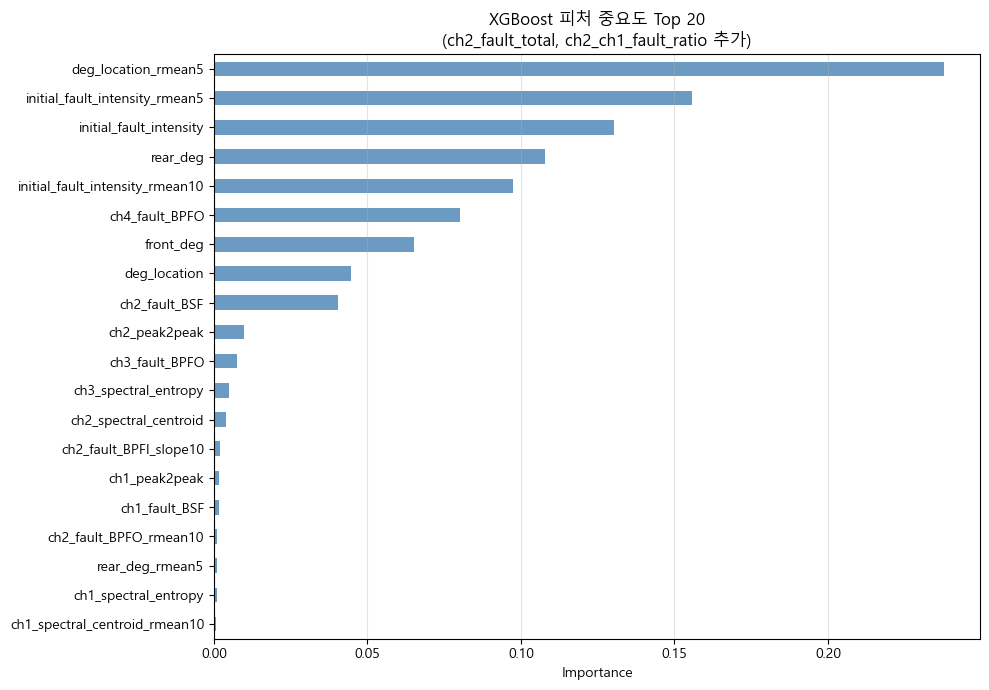

In [ ]:
# ============================================================
# 피처 중요도 확인
# ============================================================
importance = pd.Series(
    model.feature_importances_,
    index=feat_cols
).sort_values(ascending=False)

# ch2 파생 피처 중요도
ch2_feat_cols = [c for c in feat_cols if 'ch2_fault' in c]
ch2_imp       = importance[ch2_feat_cols].sum()
total_imp     = importance.sum()

print(f'\n=== 피처 중요도 ===')
print(f'ch2_fault 피처 중요도 합계: {ch2_imp:.4f} ({ch2_imp/total_imp*100:.1f}%)')
print('\n상위 15개:')
print(importance.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
importance.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('XGBoost 피처 중요도 Top 20\n(ch2_fault_total, ch2_ch1_fault_ratio 추가)')
ax.set_xlabel('Importance')
ax.grid(True, axis='x', alpha=0.35)
plt.tight_layout()
os.makedirs('../output', exist_ok=True)
plt.savefig('../output/feature_importance_ch2fault.png', bbox_inches='tight')
plt.show()


## 2. 1초 단위 LSTM + ttf - 과적합 문제 > cutoff 세밀하게 or lstm 모델 단순화 // XGBoost 돌아가기

In [ ]:
# SEQ_LEN    = 60
# BATCH_SIZE = 32
# EPOCHS     = 100
# LR         = 1e-3
# DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# fix_seed()

# TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
# VALID_CUTOFFS = [0.2, 0.5, 0.8]
# EXCLUDE_COLS  = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
#                  'rpm', 'train_id', 'test_id']


# class BearingLSTM(nn.Module):
#     def __init__(self, input_dim, hidden_dim=16, num_layers=2, dropout=0.2):
#         super().__init__()
#         self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
#                             batch_first=True, dropout=dropout)
#         self.fc   = nn.Sequential(
#             nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Linear(32, 1)
#         )
#     def forward(self, x):
#         out, _ = self.lstm(x)
#         return self.fc(out[:, -1, :]).squeeze(-1)


# def make_sequences_for_cutoff(df, input_cols, cutoffs, seq_len=SEQ_LEN):
#     """
#     각 cutoff 시점까지의 마지막 seq_len개 window를 시퀀스로 생성
#     """
#     X_list, y_list, meta_list = [], [], []

#     for tid in df['train_id'].unique():
#         df_t = df[df['train_id'] == tid].copy()
#         ttf  = float(df_t['ttf'].iloc[0])

#         for co in cutoffs:
#             cutoff_t = ttf * co
#             df_cut   = df_t[df_t['t_abs'] <= cutoff_t].sort_values(
#                 ['epoch', 'window']
#             )
#             if len(df_cut) < seq_len:
#                 continue

#             seq     = df_cut[input_cols].values[-seq_len:].astype(np.float32)
#             last_t  = float(df_cut['t_abs'].iloc[-1])
#             rul     = float(ttf - last_t)

#             X_list.append(seq)
#             y_list.append(ttf)      # TTF 예측
#             meta_list.append({
#                 'train_id': tid,
#                 'cutoff':   co,
#                 'ttf':      ttf,
#                 'RUL':      rul,
#                 't_abs':    last_t,
#             })

#     return (np.array(X_list, dtype=np.float32),
#             np.array(y_list, dtype=np.float32),
#             pd.DataFrame(meta_list))


# def train_lstm(X_train, y_train, input_dim):
#     fix_seed()

#     # TTF 정규화 (스케일 문제 해결)
#     y_mean = y_train.mean()
#     y_std  = y_train.std() + 1e-10
#     y_norm = (y_train - y_mean) / y_std  # ← 추가

#     X_t    = torch.tensor(X_train).to(DEVICE)
#     y_t    = torch.tensor(y_norm).to(DEVICE)  # ← y_norm 사용
#     loader = DataLoader(TensorDataset(X_t, y_t),
#                         batch_size=BATCH_SIZE, shuffle=True)
#     model  = BearingLSTM(input_dim).to(DEVICE)
#     opt    = torch.optim.Adam(model.parameters(), lr=LR)
#     crit   = nn.MSELoss()

#     model.train()
#     for ep in range(EPOCHS):
#         total = 0
#         for xb, yb in loader:
#             opt.zero_grad()
#             loss = crit(model(xb), yb)
#             loss.backward()
#             opt.step()
#             total += loss.item()
#         if (ep+1) % 20 == 0:
#             print(f'  Epoch {ep+1}/{EPOCHS} | Loss={total/len(loader):.4f}')

#     return model, y_mean, y_std  # ← y_mean, y_std 반환


# # ── 데이터 로드 ───────────────────────────────────────────────
# df_raw  = load_train_data()
# df_feat = add_trend_features(df_raw, windows=[5, 10], group_col='train_id')
# df_feat = df_feat.copy().fillna(0)

# input_cols = [c for c in df_feat.columns if c not in
#               ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
#                'rpm', 'train_id', 'test_id']]
# print(f'입력 피처 수: {len(input_cols)}개')

# # ── 시퀀스 생성 ───────────────────────────────────────────────
# X_train, y_train, meta_train = make_sequences_for_cutoff(
#     df_feat, input_cols, TRAIN_CUTOFFS)
# X_valid, y_valid, meta_valid = make_sequences_for_cutoff(
#     df_feat, input_cols, VALID_CUTOFFS)
# print(f'Train 시퀀스: {len(X_train)}개 | Valid 시퀀스: {len(X_valid)}개')

# # 피처 정규화
# mean_ = X_train.mean(axis=(0,1), keepdims=True)
# std_  = X_train.std(axis=(0,1),  keepdims=True) + 1e-10
# X_train_n = (X_train - mean_) / std_
# X_valid_n = (X_valid - mean_) / std_

# # ── Step 1. LOO용 모델 학습 ───────────────────────────────────
# print('\n=== Model E: 1초 LSTM + TTF 학습 ===')
# model, y_mean, y_std = train_lstm(X_train_n, y_train, len(input_cols))

# # ── Step 2. Valid 평가 ────────────────────────────────────────
# model.eval()
# with torch.no_grad():
#     x_in      = torch.tensor(X_valid_n).to(DEVICE)
#     pred_norm = model(x_in).cpu().numpy()
#     pred_ttf  = (pred_norm * y_std + y_mean).astype(np.float32)

# pred_rul_arr = np.maximum(pred_ttf - meta_valid['t_abs'].values, 0)
# act_rul_arr  = meta_valid['RUL'].values
# scores = [calc_score(a, p) for a, p in zip(act_rul_arr, pred_rul_arr)]

# print('\n=== Model E: Valid 결과 ===')
# for co in VALID_CUTOFFS:
#     mask   = meta_valid['cutoff'].values == co
#     s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
#     mae_co = float(np.mean(np.abs(act_rul_arr[mask] - pred_rul_arr[mask])))
#     print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

# avg_score = float(np.mean(scores))
# print(f'\n  전체 평균 Score: {avg_score:.4f}')

# print('\n  === Train별 20% 시점 예측 ===')
# mask_20 = meta_valid['cutoff'].values == 0.2
# df_v20  = meta_valid[mask_20].reset_index(drop=True)
# p20     = pred_rul_arr[mask_20]
# for i, row in df_v20.iterrows():
#     a = row['RUL']
#     p = p20[i]
#     s = calc_score(a, p)
#     print(f'  Train{int(row["train_id"])} | '
#           f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

# modelE_score = avg_score

# # ── Step 3. 최종 모델 학습 (전체 cutoff) ─────────────────────
# print('\n최종 모델 학습 (전체 cutoff)...')
# X_all, y_all, meta_all = make_sequences_for_cutoff(
#     df_feat, input_cols, TRAIN_CUTOFFS + VALID_CUTOFFS)

# mean_f = X_all.mean(axis=(0,1), keepdims=True)
# std_f  = X_all.std(axis=(0,1),  keepdims=True) + 1e-10
# X_all_n = (X_all - mean_f) / std_f

# # y_mean_f, y_std_f 반환 받기
# final_model, y_mean_f, y_std_f = train_lstm(X_all_n, y_all, len(input_cols))

# # ── Step 4. Test 예측 + 제출 파일 ────────────────────────────
# df_test = load_test_data()
# if df_test is not None:
#     df_test = add_trend_features(df_test, windows=[5, 10],
#                                   group_col='test_id')
#     df_test = df_test.copy().fillna(0)

#     results = []
#     final_model.eval()
#     for tid in sorted(df_test['test_id'].unique()):
#         df_t   = df_test[df_test['test_id'] == tid].sort_values(
#             ['epoch', 'window'])
#         last_t = float(df_t['t_abs'].iloc[-1])

#         if len(df_t) < SEQ_LEN:
#             seq = np.zeros((SEQ_LEN, len(input_cols)), dtype=np.float32)
#             seq[-len(df_t):] = df_t[input_cols].values.astype(np.float32)
#         else:
#             seq = df_t[input_cols].values[-SEQ_LEN:].astype(np.float32)

#         seq_n = (seq - mean_f[0]) / std_f[0]
#         x_in  = torch.tensor(seq_n[np.newaxis]).to(DEVICE)

#         with torch.no_grad():
#             pred_norm    = float(final_model(x_in).cpu().numpy()[0])
#             pred_ttf_val = pred_norm * y_std_f + y_mean_f  # ← 역변환
#         pred_rul = max(pred_ttf_val - last_t, 0)

#         results.append({'File': f'Test{tid}',
#                          'RUL_Score': round(pred_rul, 2)})
#         print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

#     os.makedirs('../output', exist_ok=True)
#     pd.DataFrame(results).to_excel(
#         '../output/modelE_submission.xlsx', index=False)
#     print('\n=== 제출 파일 (Model E) ===')
#     print(pd.DataFrame(results).to_string(index=False))

# # ── 모델 성능 비교 ────────────────────────────────────────────
# print('\n\n=== 모델 성능 비교 ===')
# print(f'  Model (XGBoost + TTF):              Score=0.8766')
# print(f'  Model G (XGBoost + TTF + weight):     Score={modelG_score:.4f}')
# print(f'  Model E (LSTM + TTF):                 Score={modelE_score:.4f}')

입력 피처 수: 207개
Train 시퀀스: 24개 | Valid 시퀀스: 12개

=== Model E: 1초 LSTM + TTF 학습 ===
  Epoch 20/100 | Loss=0.8055
  Epoch 40/100 | Loss=0.3746
  Epoch 60/100 | Loss=0.0238
  Epoch 80/100 | Loss=0.0103
  Epoch 100/100 | Loss=0.0054

=== Model E: Valid 결과 ===
  cutoff=20% | Score=0.9703 | MAE=996s
  cutoff=50% | Score=0.9609 | MAE=397s
  cutoff=80% | Score=0.8041 | MAE=1391s

  전체 평균 Score: 0.9118

  === Train별 20% 시점 예측 ===
  Train1 | 실제=60202s | 예측=60623s | Score=0.9760
  Train2 | 실제=54720s | 예측=51413s | Score=0.9197
  Train3 | 실제=42966s | 예측=43118s | Score=0.9878
  Train4 | 실제=66354s | 예측=66248s | Score=0.9978

최종 모델 학습 (전체 cutoff)...
  Epoch 20/100 | Loss=0.4793
  Epoch 40/100 | Loss=0.0094
  Epoch 60/100 | Loss=0.0033
  Epoch 80/100 | Loss=0.0014
  Epoch 100/100 | Loss=0.0019


KeyError: "['front_axial_centroid', 'front_axial_centroid_rmean5', 'front_axial_centroid_slope5', 'front_axial_centroid_rmean10', 'front_axial_centroid_slope10'] not in index"

In [ ]:
# # ============================================================
# # Model E LOO 검증 - 1초 LSTM + TTF
# # ============================================================

# print('\n=== Model E LOO 검증 (진짜 일반화 성능) ===')
# loo_results = []

# for val_id in [1, 2, 3, 4]:
#     train_ids = [t for t in [1, 2, 3, 4] if t != val_id]
#     print(f'\n--- Val=Train{val_id} | 학습=Train{train_ids} ---')

#     # Train용 시퀀스 (val_id 제외)
#     df_train_loo = df_feat[df_feat['train_id'].isin(train_ids)]
#     df_valid_loo = df_feat[df_feat['train_id'] == val_id]

#     X_tr, y_tr, meta_tr = make_sequences_for_cutoff(
#         df_train_loo, input_cols, TRAIN_CUTOFFS + VALID_CUTOFFS)
#     X_va, y_va, meta_va = make_sequences_for_cutoff(
#         df_valid_loo, input_cols, VALID_CUTOFFS)

#     if len(X_tr) == 0 or len(X_va) == 0:
#         print('  데이터 부족 → 건너뜀')
#         continue

#     print(f'  Train 시퀀스: {len(X_tr)}개 | Valid 시퀀스: {len(X_va)}개')

#     # 피처 정규화
#     mean_loo = X_tr.mean(axis=(0,1), keepdims=True)
#     std_loo  = X_tr.std(axis=(0,1),  keepdims=True) + 1e-10
#     X_tr_n   = (X_tr - mean_loo) / std_loo
#     X_va_n   = (X_va - mean_loo) / std_loo

#     # 학습
#     model_loo, y_mean_loo, y_std_loo = train_lstm(
#         X_tr_n, y_tr, len(input_cols))

#     # 검증
#     model_loo.eval()
#     with torch.no_grad():
#         x_in      = torch.tensor(X_va_n).to(DEVICE)
#         pred_norm = model_loo(x_in).cpu().numpy()
#         pred_ttf  = (pred_norm * y_std_loo + y_mean_loo).astype(np.float32)

#     pred_rul_loo = np.maximum(pred_ttf - meta_va['t_abs'].values, 0)
#     act_rul_loo  = meta_va['RUL'].values

#     scores_loo = [calc_score(a, p)
#                   for a, p in zip(act_rul_loo, pred_rul_loo)]

#     # cutoff별 결과
#     for co in VALID_CUTOFFS:
#         mask   = meta_va['cutoff'].values == co
#         s_co   = np.mean([scores_loo[i]
#                           for i in range(len(scores_loo)) if mask[i]])
#         mae_co = float(np.mean(np.abs(
#             act_rul_loo[mask] - pred_rul_loo[mask])))
#         print(f'  cutoff={int(co*100)}% | Score={s_co:.4f} | MAE={mae_co:.0f}s')

#         df_co = meta_va[mask].reset_index(drop=True)
#         p_co  = pred_rul_loo[mask]
#         for i, row in df_co.iterrows():
#             a = row['RUL']
#             p = p_co[i]
#             s = calc_score(a, p)
#             print(f'    Train{int(row["train_id"])} | '
#                   f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

#     avg_loo = float(np.mean(scores_loo))
#     print(f'  → 평균 Score: {avg_loo:.4f}')
#     loo_results.append(dict(val_id=val_id, score=avg_loo))

# print('\n=== LOO 최종 결과 ===')
# for r in loo_results:
#     print(f'  Val=Train{r["val_id"]} | Score={r["score"]:.4f}')
# print(f'  LOO 평균 Score: '
#       f'{np.mean([r["score"] for r in loo_results]):.4f}')


=== Model E LOO 검증 (진짜 일반화 성능) ===

--- Val=Train1 | 학습=Train[2, 3, 4] ---
  Train 시퀀스: 27개 | Valid 시퀀스: 3개
  Epoch 20/100 | Loss=0.7698
  Epoch 40/100 | Loss=0.3238
  Epoch 60/100 | Loss=0.0200
  Epoch 80/100 | Loss=0.0048
  Epoch 100/100 | Loss=0.0015
  cutoff=20% | Score=0.6216 | MAE=20651s
    Train1 | 실제=60202s | 예측=39551s | Score=0.6216
  cutoff=50% | Score=0.4749 | MAE=20406s
    Train1 | 실제=37992s | 예측=17586s | Score=0.4749
  cutoff=80% | Score=0.2500 | MAE=15192s
    Train1 | 실제=15192s | 예측=0s | Score=0.2500
  → 평균 Score: 0.4488

--- Val=Train2 | 학습=Train[1, 3, 4] ---
  Train 시퀀스: 27개 | Valid 시퀀스: 3개
  Epoch 20/100 | Loss=0.7864
  Epoch 40/100 | Loss=0.2965
  Epoch 60/100 | Loss=0.0129
  Epoch 80/100 | Loss=0.0041
  Epoch 100/100 | Loss=0.0011
  cutoff=20% | Score=0.5995 | MAE=8078s
    Train2 | 실제=54720s | 예측=62798s | Score=0.5995
  cutoff=50% | Score=0.4352 | MAE=8239s
    Train2 | 실제=34320s | 예측=42559s | Score=0.4352
  cutoff=80% | Score=0.1304 | MAE=8181s
    Train2 | 실제=

### 모델 비교( Base: XGBoost | 1. sec + log(RUL) VS 2. epoch + log(RUL) VS 3. sec + ttf VS 4. epoch + ttf |)

Train 전체: 27960행

  Model A: 1초 단위 + log(RUL)
  피처 수: 191개
  Train 샘플: 24개 (cutoff [0.1, 0.3, 0.4, 0.6, 0.7, 0.9])
  Valid 샘플: 12개 (cutoff [0.2, 0.5, 0.8])

  === Valid 결과 (cutoff별) ===
  cutoff=20% | 평균Score=0.5644 | MAE=23913s
  cutoff=50% | 평균Score=0.7262 | MAE=8929s
  cutoff=80% | 평균Score=0.1668 | MAE=12671s

  전체 평균 Score: 0.4858 | MAE: 15171s

  === Train별 80% 시점 예측 ===
  Train1 | 실제=15192s | 예측=24282s | Score=0.1257
  Train2 | 실제=13920s | 예측=17124s | Score=0.4503
  Train3 | 실제=11166s | 예측=38114s | Score=0.0002
  Train4 | 실제=16554s | 예측=27993s | Score=0.0912

  Model B: epoch 단위 + log(RUL)
  피처 수: 190개
  Train 샘플: 24개 (cutoff [0.1, 0.3, 0.4, 0.6, 0.7, 0.9])
  Valid 샘플: 12개 (cutoff [0.2, 0.5, 0.8])

  === Valid 결과 (cutoff별) ===
  cutoff=20% | 평균Score=0.6854 | MAE=14919s
  cutoff=50% | 평균Score=0.7200 | MAE=5948s
  cutoff=80% | 평균Score=0.1553 | MAE=11241s

  전체 평균 Score: 0.5202 | MAE: 10703s

  === Train별 80% 시점 예측 ===
  Train1 | 실제=15192s | 예측=26787s | Score=0.0710
  Train2 | 실제=13

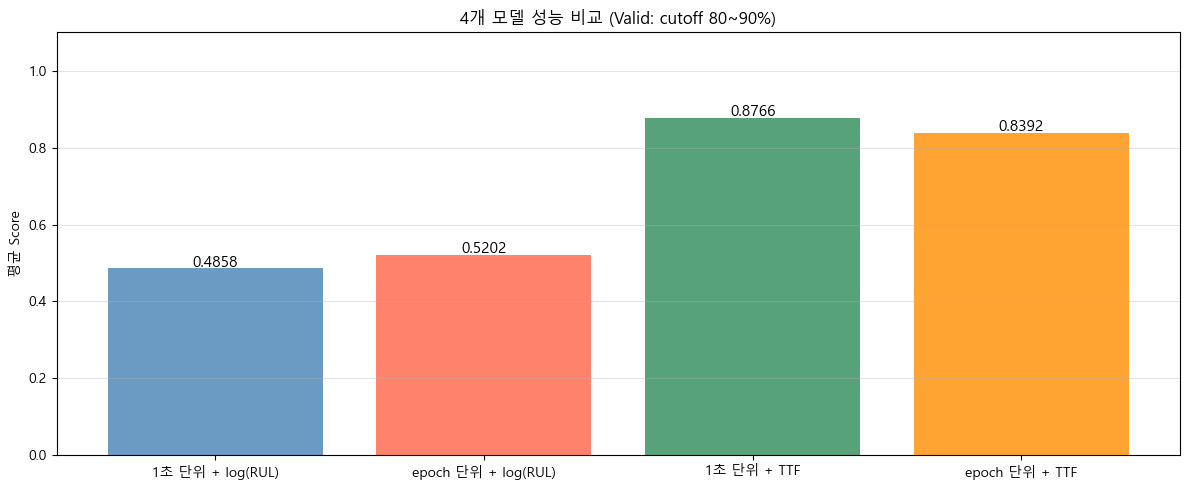


최고 성능: Model C: 1초 단위 + TTF (Score=0.8766)
→ Test 예측 시작
Test1 | 35306s (9.81h)
Test2 | 29162s (8.10h)
Test3 | 29913s (8.31h)
Test4 | 29754s (8.26h)
Test5 | 30244s (8.40h)
Test6 | 38308s (10.64h)


In [ ]:
# # ============================================================
# # model_cutoff_comparison.py
# # cutoff 기반 Train/Valid 분리 + 4개 XGBoost 모델 비교
# # ============================================================

# fix_seed()

# XGB_PARAMS = dict(
#     n_estimators=500,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=SEED,
#     verbosity=0,
# )

# # cutoff 구간
# TRAIN_CUTOFFS = [0.1, 0.3, 0.4, 0.6, 0.7, 0.9]
# VALID_CUTOFFS = [0.2, 0.5, 0.8]

# EXCLUDE_COLS = ['epoch', 'window', 'RUL', 'life_pct', 'ttf',
#                 'rpm', 'train_id', 'test_id']


# # ── cutoff 기반 샘플 생성 ─────────────────────────────────────
# def make_cutoff_samples(df, cutoffs, use_epoch=False):
#     """
#     각 cutoff 시점까지의 데이터 → 마지막 행을 예측 대상으로
#     반환: [(features, RUL, TTF), ...]
#     """
#     samples = []

#     for tid in df['train_id'].unique():
#         df_t  = df[df['train_id'] == tid].copy()
#         ttf   = df_t['ttf'].iloc[0]
#         t_max = df_t['t_abs'].max()

#         for co in cutoffs:
#             cutoff_t = ttf * co
#             df_cut   = df_t[df_t['t_abs'] <= cutoff_t]
#             if len(df_cut) == 0:
#                 continue

#             if use_epoch:
#                 # epoch 단위: 마지막 epoch의 마지막 행
#                 last_epoch = df_cut['epoch'].max()
#                 df_cut     = df_cut[df_cut['epoch'] == last_epoch]

#             last_row = df_cut.loc[df_cut['t_abs'].idxmax()]
#             rul      = float(ttf - last_row['t_abs'])
#             samples.append({
#                 'train_id': tid,
#                 'cutoff':   co,
#                 'ttf':      ttf,
#                 'RUL':      rul,
#                 't_abs':    float(last_row['t_abs']),
#                 **{c: last_row[c] for c in df_cut.columns
#                    if c not in EXCLUDE_COLS + ['train_id']}
#             })

#     return pd.DataFrame(samples)


# # ── 모델 학습 및 평가 ─────────────────────────────────────────
# def run_model(df_raw, target, use_epoch, use_log, label):
#     """
#     target: 'RUL' or 'ttf'
#     use_epoch: 1초 단위 vs epoch 단위
#     use_log: 로그 변환 여부
#     """
#     print(f'\n{"="*55}')
#     print(f'  {label}')
#     print(f'{"="*55}')

#     # 트렌드 피처 추가
#     group_col = 'train_id'
#     if use_epoch:
#         df_feat = aggregate_epoch(df_raw)
#         df_feat = add_trend_features(df_feat, windows=[3, 5],
#                                       group_col=group_col)
#     else:
#         df_feat = add_trend_features(df_raw, windows=[5, 10],
#                                       group_col=group_col)
#     df_feat = df_feat.copy().fillna(0)

#     # cutoff 샘플 생성
#     df_train_samples = make_cutoff_samples(df_feat, TRAIN_CUTOFFS,
#                                             use_epoch=use_epoch)
#     df_valid_samples = make_cutoff_samples(df_feat, VALID_CUTOFFS,
#                                             use_epoch=use_epoch)

#     feat_cols = [c for c in df_train_samples.columns
#                  if c not in ['train_id', 'cutoff', 'ttf', 'RUL', 't_abs']]

#     print(f'  피처 수: {len(feat_cols)}개')
#     print(f'  Train 샘플: {len(df_train_samples)}개 '
#           f'(cutoff {TRAIN_CUTOFFS})')
#     print(f'  Valid 샘플: {len(df_valid_samples)}개 '
#           f'(cutoff {VALID_CUTOFFS})')

#     X_train = df_train_samples[feat_cols].values
#     X_valid = df_valid_samples[feat_cols].values

#     # 타겟 설정
#     if target == 'RUL':
#         y_train_raw = df_train_samples['RUL'].values
#         y_valid_raw = df_valid_samples['RUL'].values
#     else:  # ttf
#         y_train_raw = df_train_samples['ttf'].values
#         y_valid_raw = df_valid_samples['ttf'].values

#     if use_log:
#         y_train = np.log1p(y_train_raw)
#     else:
#         y_train = y_train_raw

#     # 학습
#     fix_seed()
#     model = XGBRegressor(**XGB_PARAMS)
#     model.fit(X_train, y_train)

#     # Valid 평가
#     pred_raw = model.predict(X_valid)
#     if use_log:
#         pred_vals = np.expm1(pred_raw)
#     else:
#         pred_vals = pred_raw

#     # RUL 기준으로 score 계산
#     if target == 'ttf':
#         # ttf 예측 → RUL 변환
#         pred_rul_arr = np.maximum(
#             pred_vals - df_valid_samples['t_abs'].values, 0)
#         act_rul_arr  = df_valid_samples['RUL'].values
#     else:
#         pred_rul_arr = np.maximum(pred_vals, 0)
#         act_rul_arr  = y_valid_raw

#     scores = [calc_score(a, p)
#               for a, p in zip(act_rul_arr, pred_rul_arr)]
#     mae    = float(np.mean(np.abs(act_rul_arr - pred_rul_arr)))

#     print(f'\n  === Valid 결과 (cutoff별) ===')
#     for co in VALID_CUTOFFS:
#         mask   = df_valid_samples['cutoff'].values == co
#         s_co   = np.mean([scores[i] for i in range(len(scores)) if mask[i]])
#         mae_co = float(np.mean(np.abs(
#             act_rul_arr[mask] - pred_rul_arr[mask])))
#         print(f'  cutoff={int(co*100)}% | '
#               f'평균Score={s_co:.4f} | MAE={mae_co:.0f}s')

#     avg_score = float(np.mean(scores))
#     print(f'\n  전체 평균 Score: {avg_score:.4f} | MAE: {mae:.0f}s')

#     # Train별 cutoff 80% 예측 시각화
#     print(f'\n  === Train별 80% 시점 예측 ===')
#     mask_80 = df_valid_samples['cutoff'].values == 0.8
#     df_v80  = df_valid_samples[mask_80].reset_index(drop=True)
#     p80     = pred_rul_arr[mask_80]
#     for i, row in df_v80.iterrows():
#         a = row['RUL']
#         p = p80[i]
#         s = calc_score(a, p)
#         print(f'  Train{int(row["train_id"])} | '
#               f'실제={a:.0f}s | 예측={p:.0f}s | Score={s:.4f}')

#     return model, feat_cols, avg_score, scores


# # ── 데이터 로드 ───────────────────────────────────────────────
# df_raw = load_train_data()
# print(f'Train 전체: {len(df_raw)}행')

# # ── 4개 모델 실행 ─────────────────────────────────────────────
# MODEL_CONFIGS = [
#     dict(target='RUL', use_epoch=False, use_log=True,
#          label='Model A: 1초 단위 + log(RUL)'),
#     dict(target='RUL', use_epoch=True,  use_log=True,
#          label='Model B: epoch 단위 + log(RUL)'),
#     dict(target='ttf', use_epoch=False, use_log=False,
#          label='Model C: 1초 단위 + TTF'),
#     dict(target='ttf', use_epoch=True,  use_log=False,
#          label='Model D: epoch 단위 + TTF'),
# ]

# all_models   = {}
# score_summary = {}

# for cfg in MODEL_CONFIGS:
#     model, feat_cols, avg_score, scores = run_model(
#         df_raw, **cfg
#     )
#     key = cfg['label']
#     all_models[key]    = {'model': model, 'feat_cols': feat_cols,
#                            'cfg': cfg}
#     score_summary[key] = avg_score

# # ── 성능 비교 시각화 ──────────────────────────────────────────
# print('\n\n=== 4개 모델 성능 비교 ===')
# for label, score in sorted(score_summary.items(),
#                              key=lambda x: -x[1]):
#     print(f'  {label:45s} | Score={score:.4f}')

# fig, ax = plt.subplots(figsize=(12, 5))
# labels = [k.split(':')[1].strip() for k in score_summary.keys()]
# scores = list(score_summary.values())
# colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

# bars = ax.bar(labels, scores, color=colors, alpha=0.8)
# for bar, s in zip(bars, scores):
#     ax.text(bar.get_x() + bar.get_width()/2,
#             bar.get_height() + 0.005,
#             f'{s:.4f}', ha='center', fontsize=11)

# ax.set_ylim(0, 1.1)
# ax.set_ylabel('평균 Score')
# ax.set_title('4개 모델 성능 비교 (Valid: cutoff 80~90%)')
# ax.grid(True, axis='y', alpha=0.35)
# plt.tight_layout()
# os.makedirs('../output', exist_ok=True)
# plt.savefig('../output/model_comparison.png', bbox_inches='tight')
# plt.show()

# # ── 최고 성능 모델로 Test 예측 ───────────────────────────────
# best_label = max(score_summary, key=score_summary.get)
# best_cfg   = all_models[best_label]
# print(f'\n최고 성능: {best_label} (Score={score_summary[best_label]:.4f})')
# print('→ Test 예측 시작')

# df_test = load_test_data()
# if df_test is not None:
#     cfg      = best_cfg['cfg']
#     feat_cols = best_cfg['feat_cols']
#     model    = best_cfg['model']

#     if cfg['use_epoch']:
#         df_test_feat = aggregate_epoch(df_test)
#         df_test_feat = add_trend_features(df_test_feat, windows=[3,5],
#                                            group_col='test_id')
#     else:
#         df_test_feat = add_trend_features(df_test, windows=[5,10],
#                                            group_col='test_id')
#     df_test_feat = df_test_feat.copy().fillna(0)

#     results = []
#     for tid in sorted(df_test_feat['test_id'].unique()):
#         df_t     = df_test_feat[df_test_feat['test_id'] == tid]
#         last_row = df_t.loc[df_t['t_abs'].idxmax()]

#         feat_vals = np.array([
#             last_row[c] if c in last_row.index else 0.0
#             for c in feat_cols
#         ]).reshape(1, -1)

#         pred_raw = float(model.predict(feat_vals)[0])

#         if cfg['target'] == 'ttf':
#             pred_rul = max(pred_raw - float(last_row['t_abs']), 0)
#         else:
#             if cfg['use_log']:
#                 pred_rul = max(float(np.expm1(pred_raw)), 0)
#             else:
#                 pred_rul = max(float(pred_raw), 0)

#         results.append({'File': f'Test{tid}',
#                          'RUL_Score': round(pred_rul, 2)})
#         print(f'Test{tid} | {pred_rul:.0f}s ({pred_rul/3600:.2f}h)')

#     # result_df = pd.DataFrame(results)
#     # result_df.to_excel('../output/best_model_submission.xlsx', index=False)
#     # print('\n=== 성능 비교 best model 파일 ===')
#     # print(result_df.to_string(index=False))

이전) 1초 단위 LSTM + LOO + 로그 변환 / epoch XGBoost + LOO

## 성능 비교 